**── Instalar Bibliotecas (só na 1ª vez ou sessão nova) ────────────**

In [1]:
install.packages("dplyr")
install.packages("ggplot2")
install.packages("pheatmap")
install.packages("corrplot")
install.packages("tidyr")
install.packages("scales")
install.packages("forcats")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘vctrs’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



**── Instalar pacotes (só se der erro de versão ao carregar as bibliotecas) ───────────────────**

In [12]:
install.packages("vctrs")
install.packages("dplyr")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



Mais acções (junto do botão Executar tudo - Reiniciar sessão / Reiniciar sessão e executar tudo

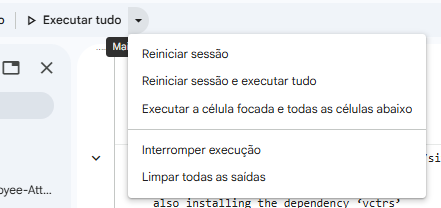

**── Carregar Bibliotecas ───────────**

In [1]:
library(dplyr)      # Manipulação de dados (filtrar, agrupar, resumir)
library(ggplot2)    # Visualizações avançadas e personalizáveis
library(pheatmap)   # Heatmaps de correlação com clustering automático
library(corrplot)   # Visualização alternativa de matrizes de correlação
library(tidyr)      # Transformar dados (ex: wide → long, tratar NAs)
library(scales)     # Formatar eixos dos gráficos (%, moeda, etc.)
library(forcats)    # Trabalhar com variáveis categóricas (reordenar, agrupar)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


corrplot 0.95 loaded



**── Importar Dados ──**

In [2]:
dfProjeto1 <- read.csv("/content/WA_Fn-UseC_-HR-Employee-Attrition.csv")

**── FASE 1: Exploração Inicial ────────────────────────────────────**



In [3]:
dim(dfProjeto1)         # Dimensões: linhas × colunas

[1] 1470   35

In [4]:
colnames(dfProjeto1)    # Nomes de todas as colunas

[1] "Age"                      "Attrition"               
 [3] "BusinessTravel"           "DailyRate"               
 [5] "Department"               "DistanceFromHome"        
 [7] "Education"                "EducationField"          
 [9] "EmployeeCount"            "EmployeeNumber"          
[11] "EnvironmentSatisfaction"  "Gender"                  
[13] "HourlyRate"               "JobInvolvement"          
[15] "JobLevel"                 "JobRole"                 
[17] "JobSatisfaction"          "MaritalStatus"           
[19] "MonthlyIncome"            "MonthlyRate"             
[21] "NumCompaniesWorked"       "Over18"                  
[23] "OverTime"                 "PercentSalaryHike"       
[25] "PerformanceRating"        "RelationshipSatisfaction"
[27] "StandardHours"            "StockOptionLevel"        
[29] "TotalWorkingYears"        "TrainingTimesLastYear"   
[31] "WorkLifeBalance"          "YearsAtCompany"          
[33] "YearsInCurrentRole"       "YearsSinceLastPromotion" 
[35] "YearsWithCurrManager"

In [5]:
str(dfProjeto1)         # Estrutura: tipos de dados + primeiros valores

'data.frame':	1470 obs. of  35 variables:
 $ Age                     : int  41 49 37 33 27 32 59 30 38 36 ...
 $ Attrition               : chr  "Yes" "No" "Yes" "No" ...
 $ BusinessTravel          : chr  "Travel_Rarely" "Travel_Frequently" "Travel_Rarely" "Travel_Frequently" ...
 $ DailyRate               : int  1102 279 1373 1392 591 1005 1324 1358 216 1299 ...
 $ Department              : chr  "Sales" "Research & Development" "Research & Development" "Research & Development" ...
 $ DistanceFromHome        : int  1 8 2 3 2 2 3 24 23 27 ...
 $ Education               : int  2 1 2 4 1 2 3 1 3 3 ...
 $ EducationField          : chr  "Life Sciences" "Life Sciences" "Other" "Life Sciences" ...
 $ EmployeeCount           : int  1 1 1 1 1 1 1 1 1 1 ...
 $ EmployeeNumber          : int  1 2 4 5 7 8 10 11 12 13 ...
 $ EnvironmentSatisfaction : int  2 3 4 4 1 4 3 4 4 3 ...
 $ Gender                  : chr  "Female" "Male" "Male" "Female" ...
 $ HourlyRate              : int  94 61 92 56 40 79 8

In [6]:
head(dfProjeto1)        # Primeiras 6 linhas

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,⋯,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
,<int>,<chr>,<chr>,<int>,<chr>,<int>,<int>,<chr>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,⋯,1,80,0,8,0,1,6,4,0,5
2,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,⋯,4,80,1,10,3,3,10,7,1,7
3,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,⋯,2,80,0,7,3,3,0,0,0,0
4,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,⋯,3,80,0,8,3,3,8,7,3,0
5,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,⋯,4,80,1,6,3,3,2,2,2,2
6,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,⋯,3,80,0,8,2,2,7,7,3,6


In [7]:
dfProjeto1            # Todas as linhas

Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,⋯,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
<int>,<chr>,<chr>,<int>,<chr>,<int>,<int>,<chr>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,⋯,1,80,0,8,0,1,6,4,0,5
49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,⋯,4,80,1,10,3,3,10,7,1,7
37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,⋯,2,80,0,7,3,3,0,0,0,0
33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,⋯,3,80,0,8,3,3,8,7,3,0
27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,⋯,4,80,1,6,3,3,2,2,2,2
32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,⋯,3,80,0,8,2,2,7,7,3,6
59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,⋯,1,80,3,12,3,2,1,0,0,0
30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,⋯,2,80,1,1,2,3,1,0,0,0
38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,⋯,2,80,0,10,2,3,9,7,1,8


In [8]:
tail(dfProjeto1)        # Últimas 6 linhas

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,⋯,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
,<int>,<chr>,<chr>,<int>,<chr>,<int>,<int>,<chr>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1465,26,No,Travel_Rarely,1167,Sales,5,3,Other,1,2060,⋯,4,80,0,5,2,3,4,2,0,0
1466,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,⋯,3,80,1,17,3,3,5,2,0,3
1467,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,⋯,1,80,1,9,5,3,7,7,1,7
1468,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,⋯,2,80,1,6,0,3,6,2,0,3
1469,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,⋯,4,80,0,17,3,2,9,6,0,8
1470,34,No,Travel_Rarely,628,Research & Development,8,3,Medical,1,2068,⋯,1,80,0,6,3,4,4,3,1,2


In [9]:
summary(dfProjeto1)     # Resumo estatístico geral

      Age         Attrition         BusinessTravel       DailyRate     
 Min.   :18.00   Length:1470        Length:1470        Min.   : 102.0  
 1st Qu.:30.00   Class :character   Class :character   1st Qu.: 465.0  
 Median :36.00   Mode  :character   Mode  :character   Median : 802.0  
 Mean   :36.92                                         Mean   : 802.5  
 3rd Qu.:43.00                                         3rd Qu.:1157.0  
 Max.   :60.00                                         Max.   :1499.0  
  Department        DistanceFromHome   Education     EducationField    
 Length:1470        Min.   : 1.000   Min.   :1.000   Length:1470       
 Class :character   1st Qu.: 2.000   1st Qu.:2.000   Class :character  
 Mode  :character   Median : 7.000   Median :3.000   Mode  :character  
                    Mean   : 9.193   Mean   :2.913                     
                    3rd Qu.:14.000   3rd Qu.:4.000                     
                    Max.   :29.000   Max.   :5.000              

**── FASE 2 — Qualidade dos Dados ───────────────────────────**

**── 2.1 Valores em falta ─────────────────────────────────────────**



In [10]:
sum(is.na(dfProjeto1)) # total de NAs no dataset inteiro

[1] 0

In [11]:
colSums(is.na(dfProjeto1))[colSums(is.na(dfProjeto1)) > 0]   # NAs por coluna (só mostra as que têm NAs)

named numeric(0)

**── 2.2 Linhas duplicadas ────────────────────────────────────────**



In [12]:
sum(duplicated(dfProjeto1))          # Quantas linhas duplicadas existem?

[1] 0

**── 2.3 Colunas constantes ───────────────────────────────────────**

In [13]:
colunas_constantes <- names(which(sapply(dfProjeto1, function(x) length(unique(x))) == 1))     # Identificar colunas com apenas 1 valor único
colunas_constantes

[1] "EmployeeCount" "Over18"        "StandardHours"

In [14]:
dfProjeto1 <- dfProjeto1 %>% select(-all_of(colunas_constantes))   # Remover essas colunas — não acrescentam nada à análise

In [15]:
dim(dfProjeto1)    # Confirmar resultado

[1] 1470   32

**── 2.4 Corrigir tipos de variáveis ─────────────────────────────**

In [16]:
# Converter categóricas (texto → factor)
dfProjeto1$Attrition     <- as.factor(dfProjeto1$Attrition)
dfProjeto1$Gender        <- as.factor(dfProjeto1$Gender)
dfProjeto1$Department    <- as.factor(dfProjeto1$Department)
dfProjeto1$MaritalStatus <- as.factor(dfProjeto1$MaritalStatus)
dfProjeto1$JobRole       <- as.factor(dfProjeto1$JobRole)

In [17]:
# Converter escalas ordinais (número → factor ordenado)
dfProjeto1$JobLevel          <- as.factor(dfProjeto1$JobLevel)
dfProjeto1$JobSatisfaction   <- as.factor(dfProjeto1$JobSatisfaction)
dfProjeto1$WorkLifeBalance   <- as.factor(dfProjeto1$WorkLifeBalance)
dfProjeto1$PerformanceRating <- as.factor(dfProjeto1$PerformanceRating)

In [18]:
# Verificar resultado
str(dfProjeto1)

'data.frame':	1470 obs. of  32 variables:
 $ Age                     : int  41 49 37 33 27 32 59 30 38 36 ...
 $ Attrition               : Factor w/ 2 levels "No","Yes": 2 1 2 1 1 1 1 1 1 1 ...
 $ BusinessTravel          : chr  "Travel_Rarely" "Travel_Frequently" "Travel_Rarely" "Travel_Frequently" ...
 $ DailyRate               : int  1102 279 1373 1392 591 1005 1324 1358 216 1299 ...
 $ Department              : Factor w/ 3 levels "Human Resources",..: 3 2 2 2 2 2 2 2 2 2 ...
 $ DistanceFromHome        : int  1 8 2 3 2 2 3 24 23 27 ...
 $ Education               : int  2 1 2 4 1 2 3 1 3 3 ...
 $ EducationField          : chr  "Life Sciences" "Life Sciences" "Other" "Life Sciences" ...
 $ EmployeeNumber          : int  1 2 4 5 7 8 10 11 12 13 ...
 $ EnvironmentSatisfaction : int  2 3 4 4 1 4 3 4 4 3 ...
 $ Gender                  : Factor w/ 2 levels "Female","Male": 1 2 2 1 2 2 1 2 2 2 ...
 $ HourlyRate              : int  94 61 92 56 40 79 81 67 44 94 ...
 $ JobInvolvement          

**── FASE 3: Separar Tipos de Variáveis ───────────────────────────**

**── 3.1 Seleccionar colunas numéricas ────────────────────────────**

In [19]:
colunas_num <- dfProjeto1 %>%
  select(where(is.numeric)) %>%
  colnames()

dfNum <- dfProjeto1 %>% select(all_of(colunas_num))

In [20]:
# Confirmar quais são
colunas_num

[1] "Age"                      "DailyRate"               
 [3] "DistanceFromHome"         "Education"               
 [5] "EmployeeNumber"           "EnvironmentSatisfaction" 
 [7] "HourlyRate"               "JobInvolvement"          
 [9] "MonthlyIncome"            "MonthlyRate"             
[11] "NumCompaniesWorked"       "PercentSalaryHike"       
[13] "RelationshipSatisfaction" "StockOptionLevel"        
[15] "TotalWorkingYears"        "TrainingTimesLastYear"   
[17] "YearsAtCompany"           "YearsInCurrentRole"      
[19] "YearsSinceLastPromotion"  "YearsWithCurrManager"

**── 3.2 Seleccionar colunas categóricas ──────────────────────────**

In [21]:
colunas_cat <- dfProjeto1 %>%
  select(where(is.factor)) %>%
  colnames()

dfCat <- dfProjeto1 %>% select(all_of(colunas_cat))

In [22]:
# Confirmar quais são
colunas_cat

[1] "Attrition"         "Department"        "Gender"           
[4] "JobLevel"          "JobRole"           "JobSatisfaction"  
[7] "MaritalStatus"     "PerformanceRating" "WorkLifeBalance"

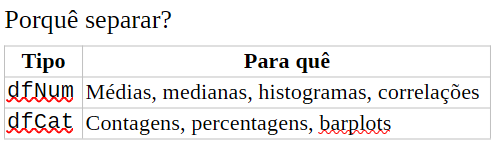


**── 3.3 Criar versões filtradas por Attrition ────────────────────**

In [36]:
# Quem saiu
dfSaiu     <- dfProjeto1 %>% filter(Attrition == "Yes")
dfNumSaiu  <- dfSaiu %>% select(all_of(colunas_num))
dfCatSaiu  <- dfSaiu %>% select(all_of(colunas_cat))

In [37]:
# Quem ficou
dfFicou    <- dfProjeto1 %>% filter(Attrition == "No")
dfNumFicou <- dfFicou %>% select(all_of(colunas_num))
dfCatFicou <- dfFicou %>% select(all_of(colunas_cat))

**── FASE 4: Estatísticas Descritivas ──────────────────────────**



**── 4.1 Resumo geral ─────────────────────────────────────────────**

- Para analisar só quem saiu: summary(dfNumSaiu)
- Para analisar só quem ficou: summary(dfNumFicou)

In [23]:
summary(dfNum)

      Age          DailyRate      DistanceFromHome   Education    
 Min.   :18.00   Min.   : 102.0   Min.   : 1.000   Min.   :1.000  
 1st Qu.:30.00   1st Qu.: 465.0   1st Qu.: 2.000   1st Qu.:2.000  
 Median :36.00   Median : 802.0   Median : 7.000   Median :3.000  
 Mean   :36.92   Mean   : 802.5   Mean   : 9.193   Mean   :2.913  
 3rd Qu.:43.00   3rd Qu.:1157.0   3rd Qu.:14.000   3rd Qu.:4.000  
 Max.   :60.00   Max.   :1499.0   Max.   :29.000   Max.   :5.000  
 EmployeeNumber   EnvironmentSatisfaction   HourlyRate     JobInvolvement
 Min.   :   1.0   Min.   :1.000           Min.   : 30.00   Min.   :1.00  
 1st Qu.: 491.2   1st Qu.:2.000           1st Qu.: 48.00   1st Qu.:2.00  
 Median :1020.5   Median :3.000           Median : 66.00   Median :3.00  
 Mean   :1024.9   Mean   :2.722           Mean   : 65.89   Mean   :2.73  
 3rd Qu.:1555.8   3rd Qu.:4.000           3rd Qu.: 83.75   3rd Qu.:3.00  
 Max.   :2068.0   Max.   :4.000           Max.   :100.00   Max.   :4.00  
 MonthlyIncom

**── 4.2 Tabela resumo personalizada ──────────────────────────────**

- Para analisar só quem saiu substitui dfNum por dfNumSaiu
- Para analisar só quem ficou substitui dfNum por dfNumFicou

In [24]:
dfNum %>%
  summarise(across(everything(), list(
    media   = ~round(mean(.), 1),
    mediana = ~round(median(.), 1),
    sd      = ~round(sd(.), 1),
    min     = ~min(.),
    max     = ~max(.)
  ))) %>%
  tidyr::pivot_longer(everything(),
    names_to  = c("variavel", "estatistica"),
    names_sep = "_",
    values_to = "valor") %>%
  tidyr::pivot_wider(names_from = estatistica, values_from = valor)

variavel,media,mediana,sd,min,max
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Age,36.9,36.0,9.1,18,60
DailyRate,802.5,802.0,403.5,102,1499
DistanceFromHome,9.2,7.0,8.1,1,29
Education,2.9,3.0,1.0,1,5
EmployeeNumber,1024.9,1020.5,602.0,1,2068
EnvironmentSatisfaction,2.7,3.0,1.1,1,4
HourlyRate,65.9,66.0,20.3,30,100
JobInvolvement,2.7,3.0,0.7,1,4
MonthlyIncome,6502.9,4919.0,4708.0,1009,19999


**── 4.3 Foco nas variáveis chave ─────────────────────────────────**

- Para analisar só quem saiu substitui dfProjeto1 por dfSaiu
- Para analisar só quem ficou substitui dfProjeto1 por dfFicou

In [33]:
# Idade
cat("=== Idade ===\n")
cat("Média:   ", round(mean(dfProjeto1$Age), 1), "\n")
cat("Mediana: ", median(dfProjeto1$Age), "\n")
cat("SD:      ", round(sd(dfProjeto1$Age), 1), "\n")
cat("Min/Max: ", min(dfProjeto1$Age), "/", max(dfProjeto1$Age), "\n\n")

=== Idade ===
Média:    36.9 
Mediana:  36 
SD:       9.1 
Min/Max:  18 / 60 



In [38]:
# Comparação directa: todo o dataset vs quem saiu vs quem ficou
cat("=== Idade ===\n")
cat("Todos:       ", round(mean(dfProjeto1$Age), 1), "\n")
cat("Quem saiu:   ", round(mean(dfSaiu$Age), 1), "\n")
cat("Quem ficou:  ", round(mean(dfFicou$Age), 1), "\n\n")

=== Idade ===
Todos:        36.9 
Quem saiu:    33.6 
Quem ficou:   37.6 



In [34]:
# Salário mensal
cat("=== Salário Mensal ===\n")
cat("Média:   ", round(mean(dfProjeto1$MonthlyIncome), 1), "\n")
cat("Mediana: ", median(dfProjeto1$MonthlyIncome), "\n")
cat("SD:      ", round(sd(dfProjeto1$MonthlyIncome), 1), "\n")
cat("Min/Max: ", min(dfProjeto1$MonthlyIncome), "/", max(dfProjeto1$MonthlyIncome), "\n\n")


=== Salário Mensal ===
Média:    6502.9 
Mediana:  4919 
SD:       4708 
Min/Max:  1009 / 19999 



In [40]:
# Comparação directa: todo o dataset vs quem saiu vs quem ficou
cat("=== Salário Mensal ===\n")
cat("Todos:       ", round(mean(dfProjeto1$MonthlyIncome), 1), "\n")
cat("Quem saiu:   ", round(mean(dfSaiu$MonthlyIncome), 1), "\n")
cat("Quem ficou:  ", round(mean(dfFicou$MonthlyIncome), 1), "\n\n")

=== Salário Mensal ===
Todos:        6502.9 
Quem saiu:    4787.1 
Quem ficou:   6832.7 



In [35]:
# Anos na empresa
cat("=== Anos na Empresa ===\n")
cat("Média:   ", round(mean(dfProjeto1$YearsAtCompany), 1), "\n")
cat("Mediana: ", median(dfProjeto1$YearsAtCompany), "\n")
cat("SD:      ", round(sd(dfProjeto1$YearsAtCompany), 1), "\n")
cat("Min/Max: ", min(dfProjeto1$YearsAtCompany), "/", max(dfProjeto1$YearsAtCompany), "\n")

=== Anos na Empresa ===
Média:    7 
Mediana:  5 
SD:       6.1 
Min/Max:  0 / 40 


In [41]:
# Comparação directa: todo o dataset vs quem saiu vs quem ficou
cat("=== Anos na Empresa ===\n")
cat("Todos:       ", round(mean(dfProjeto1$YearsAtCompany), 1), "\n")
cat("Quem saiu:   ", round(mean(dfSaiu$YearsAtCompany), 1), "\n")
cat("Quem ficou:  ", round(mean(dfFicou$YearsAtCompany), 1), "\n")

=== Anos na Empresa ===
Todos:        7 
Quem saiu:    5.1 
Quem ficou:   7.4 


**── 4.4 Frequências das categóricas ──────────────────────────────**

**Contagem e percentagem**

In [39]:
# Attrition — quantos saíram vs ficaram
table(dfProjeto1$Attrition)
round(prop.table(table(dfProjeto1$Attrition)) * 100, 2)



  No  Yes 
1233  237 


   No   Yes 
83.88 16.12 

In [31]:
# Departament
table(dfProjeto1$Department)
round(prop.table(table(dfProjeto1$Department)) * 100, 2)


       Human Resources Research & Development                  Sales 
                    63                    961                    446 


       Human Resources Research & Development                  Sales 
                  4.29                  65.37                  30.34 

In [32]:
# Gender
table(dfProjeto1$Gender)
round(prop.table(table(dfProjeto1$Gender)) * 100, 2)


Female   Male 
   588    882 


Female   Male 
    40     60 

**── FASE 5: Distribuições ─────────────────────────────────────────**

Para comparar grupos substituir dfProjeto1 por dfSaiu e dfFicou em células separadas

**── 5.1 Distribuição de Idade ────────────────────────────────────**

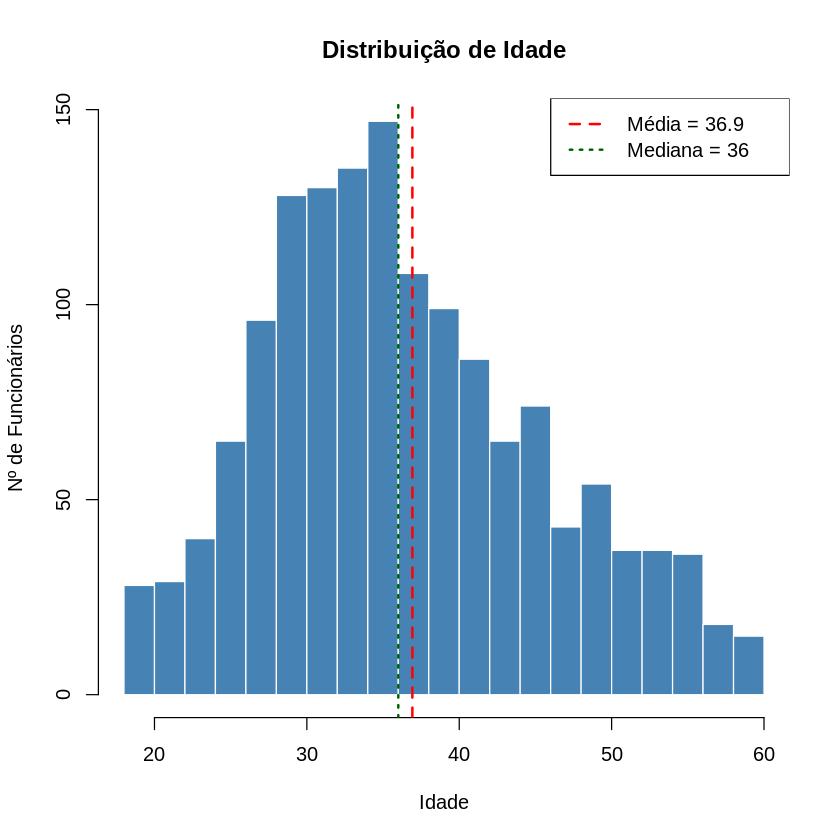

In [42]:
hist(dfProjeto1$Age,
     breaks = 15,
     main   = "Distribuição de Idade",
     xlab   = "Idade",
     ylab   = "Nº de Funcionários",
     col    = "steelblue",
     border = "white")
abline(v = mean(dfProjeto1$Age),   col = "red",       lty = 2, lwd = 2)
abline(v = median(dfProjeto1$Age), col = "darkgreen", lty = 3, lwd = 2)
legend("topright",
       legend = c(paste("Média =",   round(mean(dfProjeto1$Age), 1)),
                  paste("Mediana =", median(dfProjeto1$Age))),
       col  = c("red", "darkgreen"),
       lty  = c(2, 3), lwd = 2)

**── 5.2 Distribuição de Salário Mensal ───────────────────────────**

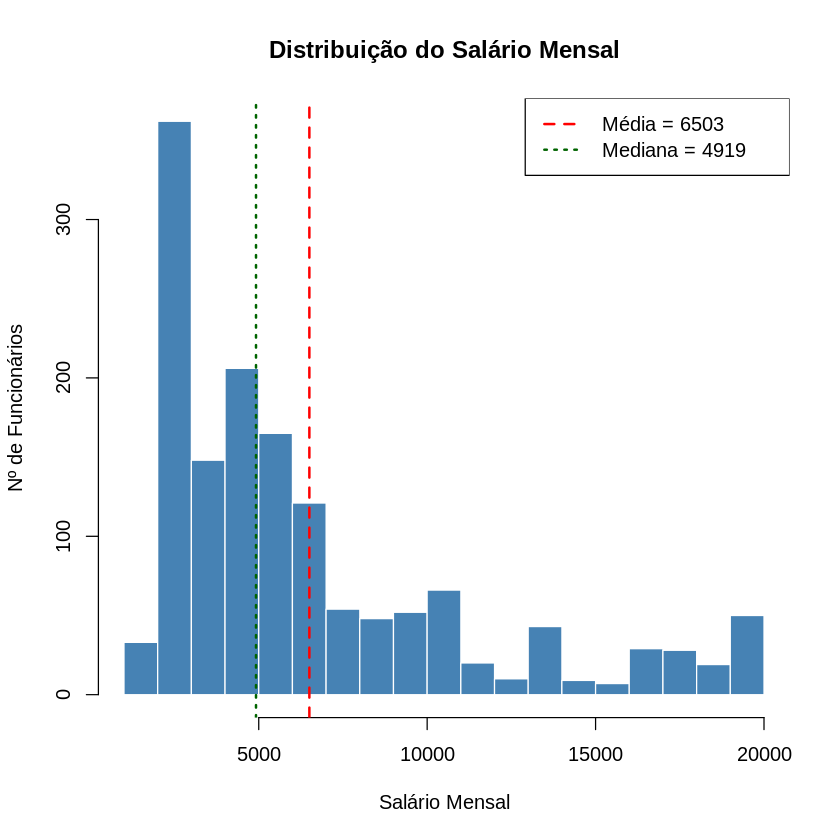

In [46]:
hist(dfProjeto1$MonthlyIncome,
     breaks = 15,
     main   = "Distribuição do Salário Mensal",
     xlab   = "Salário Mensal",
     ylab   = "Nº de Funcionários",
     col    = "steelblue",
     border = "white")
abline(v = mean(dfProjeto1$MonthlyIncome),   col = "red",       lty = 2, lwd = 2)
abline(v = median(dfProjeto1$MonthlyIncome), col = "darkgreen", lty = 3, lwd = 2)
legend("topright",
       legend = c(paste("Média =",   round(mean(dfProjeto1$MonthlyIncome), 0)),
                  paste("Mediana =", median(dfProjeto1$MonthlyIncome))),
       col  = c("red", "darkgreen"),
       lty  = c(2, 3), lwd = 2)

**── 5.3 Distribuição de Anos na Empresa ──────────────────────────**

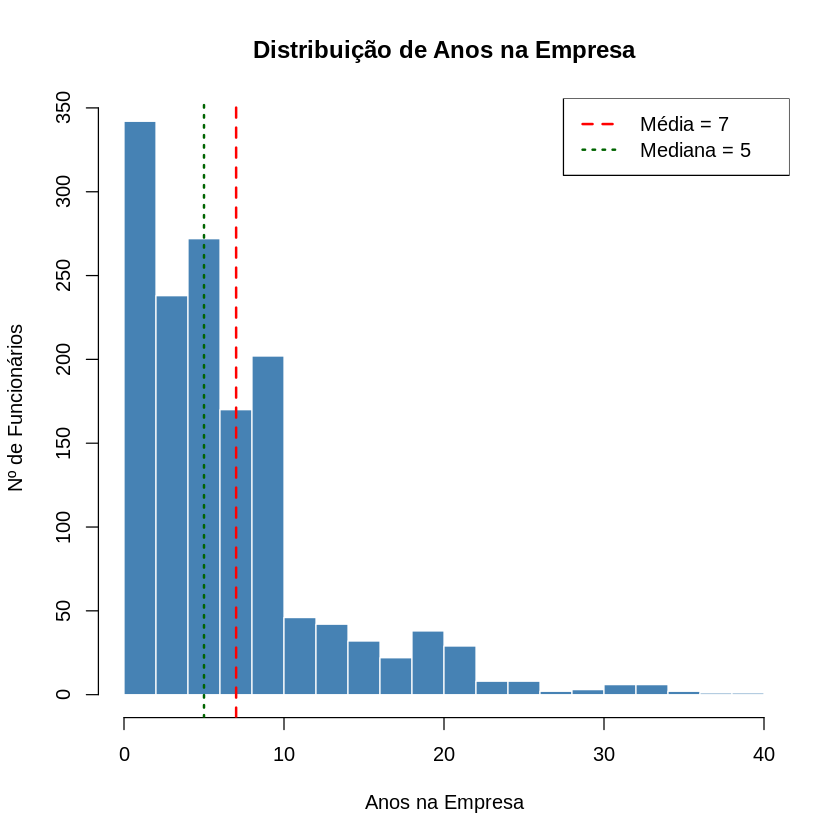

In [48]:
hist(dfProjeto1$YearsAtCompany,
     breaks = 15,
     main   = "Distribuição de Anos na Empresa",
     xlab   = "Anos na Empresa",
     ylab   = "Nº de Funcionários",
     col    = "steelblue",
     border = "white")
abline(v = mean(dfProjeto1$YearsAtCompany),   col = "red",       lty = 2, lwd = 2)
abline(v = median(dfProjeto1$YearsAtCompany), col = "darkgreen", lty = 3, lwd = 2)
legend("topright",
       legend = c(paste("Média =",   round(mean(dfProjeto1$YearsAtCompany), 1)),
                  paste("Mediana =", median(dfProjeto1$YearsAtCompany))),
       col  = c("red", "darkgreen"),
       lty  = c(2, 3), lwd = 2)

**── FASE 6: Outliers (Boxplots) ───────────────────────────────────**

**── 6.1 Salário Mensal ───────────────────────────────────────────**

Para comparar grupos substituir dfProjeto1 por dfSaiu e dfFicou em células separadas

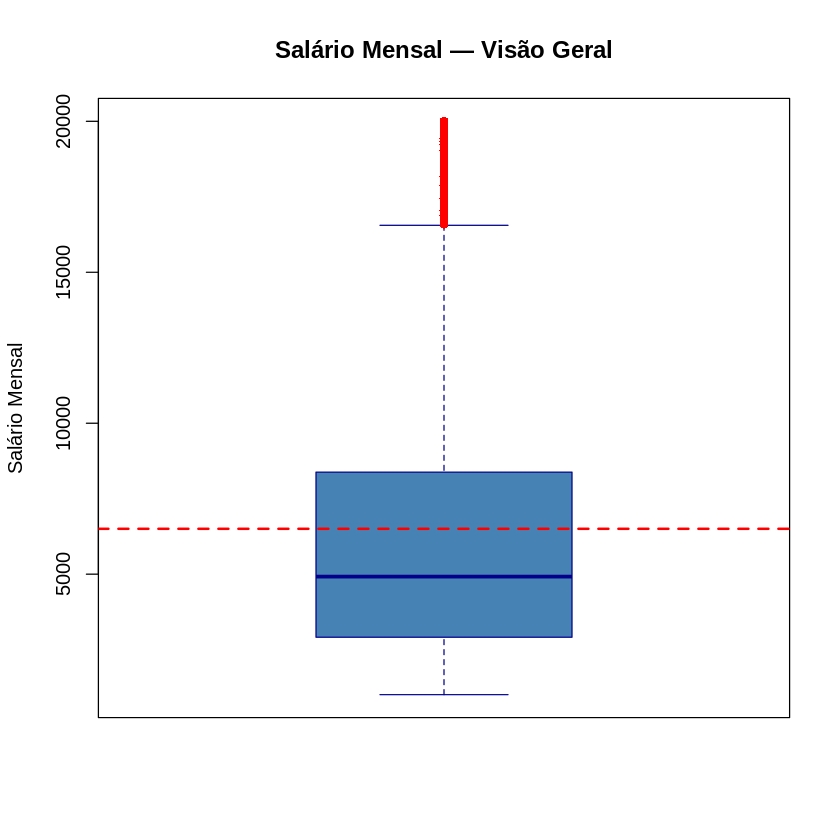

In [49]:
boxplot(dfProjeto1$MonthlyIncome,
        main     = "Salário Mensal — Visão Geral",
        ylab     = "Salário Mensal",
        col      = "steelblue",
        border   = "darkblue",
        outcol   = "red",
        outpch   = 16)
abline(h = mean(dfProjeto1$MonthlyIncome), col = "red", lty = 2, lwd = 2)

**── 6.2 Salário por Nível de Cargo ───────────────────────────────**

Para comparar grupos substituir dfProjeto1 por dfSaiu e dfFicou em células separadas

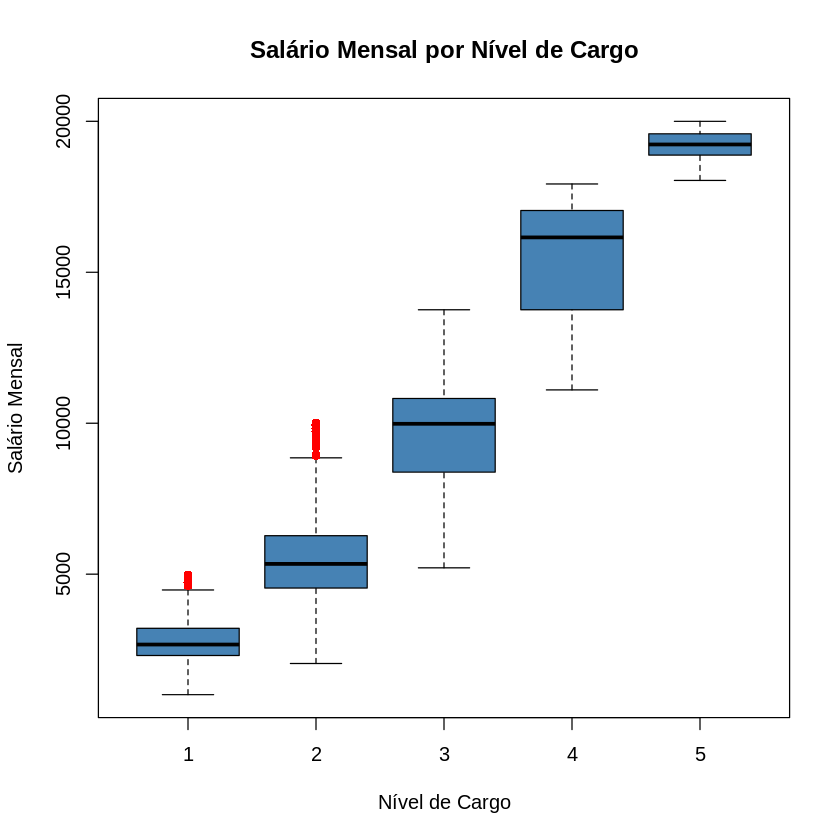

In [51]:
boxplot(MonthlyIncome ~ JobLevel,
        data   = dfProjeto1,
        main   = "Salário Mensal por Nível de Cargo",
        xlab   = "Nível de Cargo",
        ylab   = "Salário Mensal",
        col    = "steelblue",
        border = "black",
        outcol = "red",
        outpch = 16)

**── 6.3 Salário por Attrition ────────────────────────────────────**

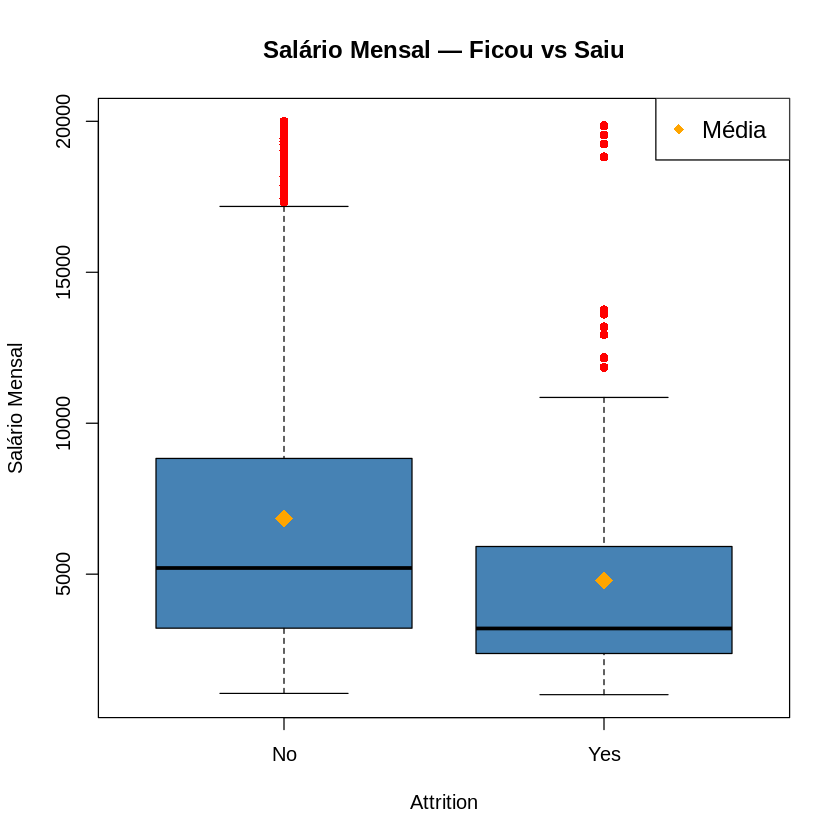

In [53]:
boxplot(MonthlyIncome ~ Attrition,
        data   = dfProjeto1,
        main   = "Salário Mensal — Ficou vs Saiu",
        xlab   = "Attrition",
        ylab   = "Salário Mensal",
        col    = "steelblue",
        border = "black",
        outcol = "red",
        outpch = 16)
points(1, mean(dfFicou$MonthlyIncome), pch = 18, col = "orange", cex = 2)
points(2, mean(dfSaiu$MonthlyIncome),  pch = 18, col = "orange", cex = 2)
legend("topright",
       legend = "Média",
       pch    = 18,
       col    = "orange",
       cex    = 1.2)

**── 6.4 Idade por Attrition ──────────────────────────────────────**

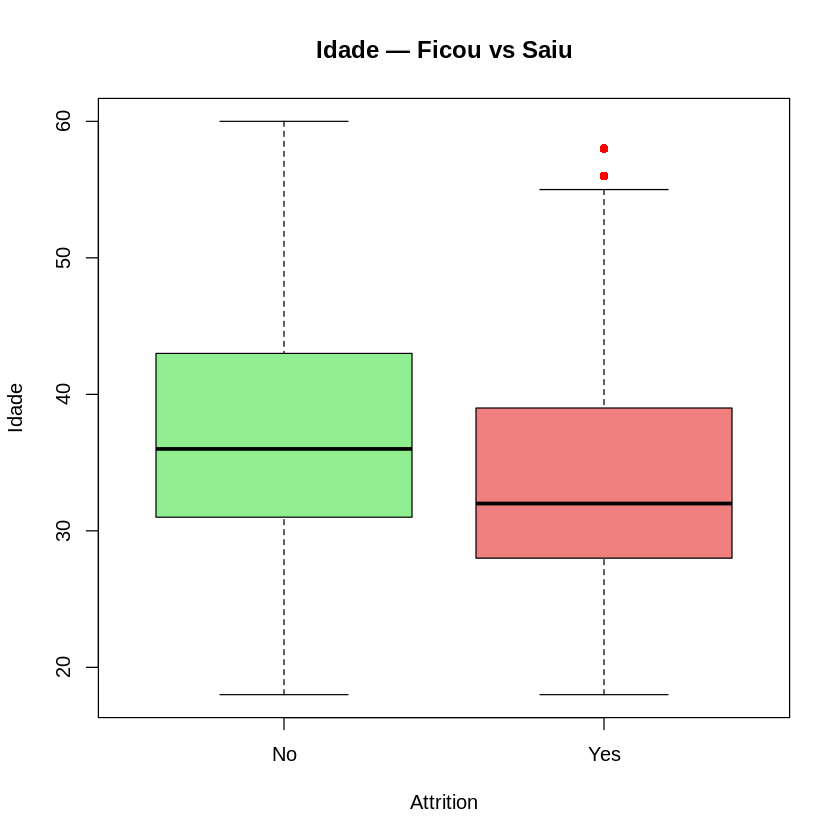

In [54]:
boxplot(Age ~ Attrition,
        data   = dfProjeto1,
        main   = "Idade — Ficou vs Saiu",
        xlab   = "Attrition",
        ylab   = "Idade",
        col    = c("lightgreen", "lightcoral"),
        border = "black",
        outcol = "red",
        outpch = 16)

**── 6.5 Anos na Empresa por Attrition ────────────────────────────**

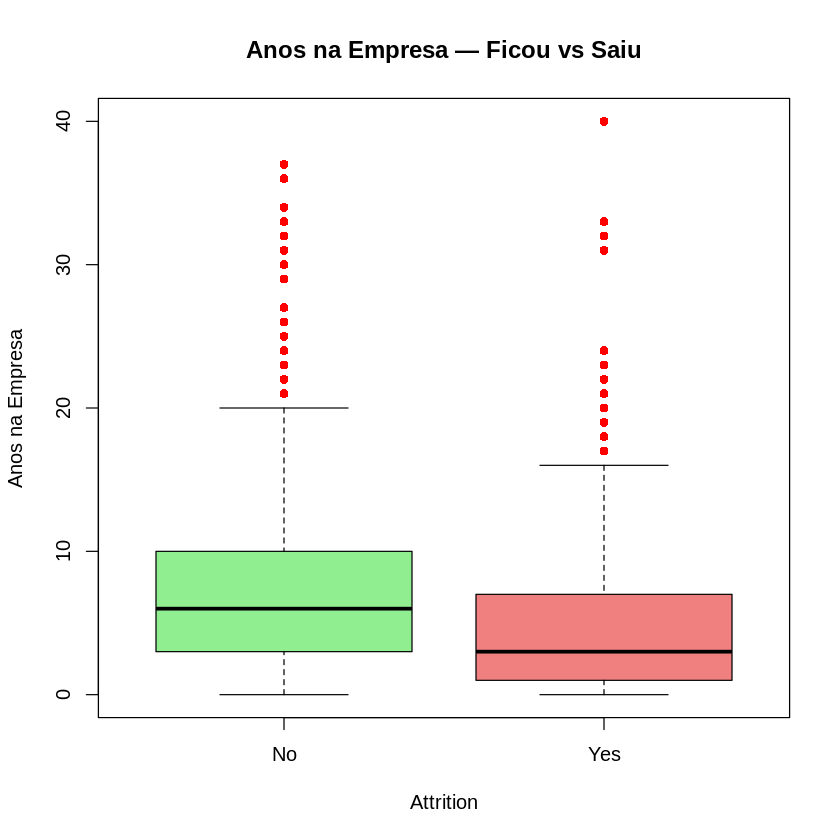

In [55]:
boxplot(YearsAtCompany ~ Attrition,
        data   = dfProjeto1,
        main   = "Anos na Empresa — Ficou vs Saiu",
        xlab   = "Attrition",
        ylab   = "Anos na Empresa",
        col    = c("lightgreen", "lightcoral"),
        border = "black",
        outcol = "red",
        outpch = 16)

**── FASE 7: Variáveis Categóricas ────────────────────────────────**

**── 7.1 Attrition ────────────────────────────────────────────────**


   No   Yes 
83.88 16.12 

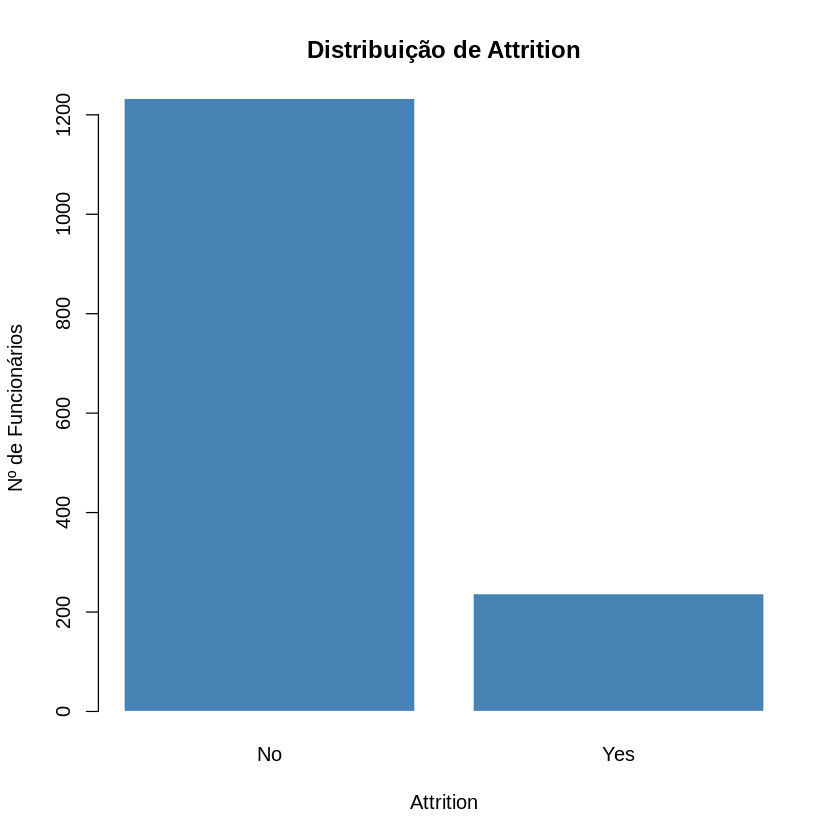

In [56]:
barplot(table(dfProjeto1$Attrition),
        main   = "Distribuição de Attrition",
        xlab   = "Attrition",
        ylab   = "Nº de Funcionários",
        col    = "steelblue",
        border = "white")

# Percentagens
round(prop.table(table(dfProjeto1$Attrition)) * 100, 2)

**── 7.2 Department ────────────────────────────────────────────────**

Para comparar grupos substitui dfProjeto1 por dfSaiu ou dfFicou em células separadas.


Research & Development                  Sales        Human Resources 
                 65.37                  30.34                   4.29 

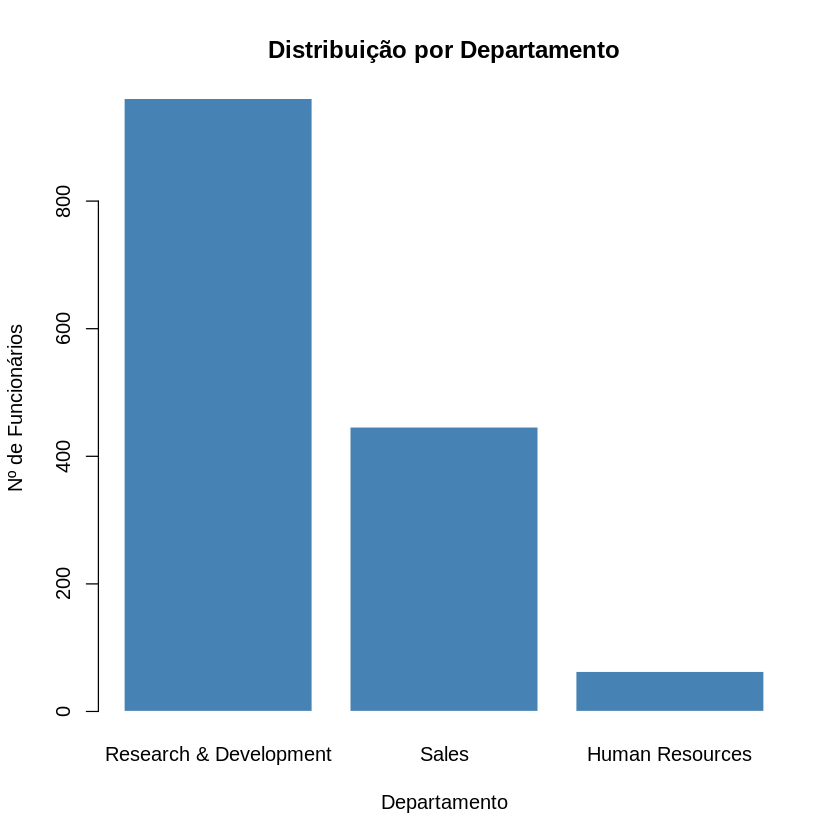

In [57]:
barplot(sort(table(dfProjeto1$Department), decreasing = TRUE),
        main   = "Distribuição por Departamento",
        xlab   = "Departamento",
        ylab   = "Nº de Funcionários",
        col    = "steelblue",
        border = "white")

# Percentagens
round(prop.table(sort(table(dfProjeto1$Department), decreasing = TRUE)) * 100, 2)


**── 7.3 Job Role ────────────────────────────────────────────────**

Para comparar grupos substitui dfProjeto1 por dfSaiu ou dfFicou em células separadas.


          Sales Executive        Research Scientist     Laboratory Technician 
                    22.18                     19.86                     17.62 
   Manufacturing Director Healthcare Representative                   Manager 
                     9.86                      8.91                      6.94 
     Sales Representative         Research Director           Human Resources 
                     5.65                      5.44                      3.54 

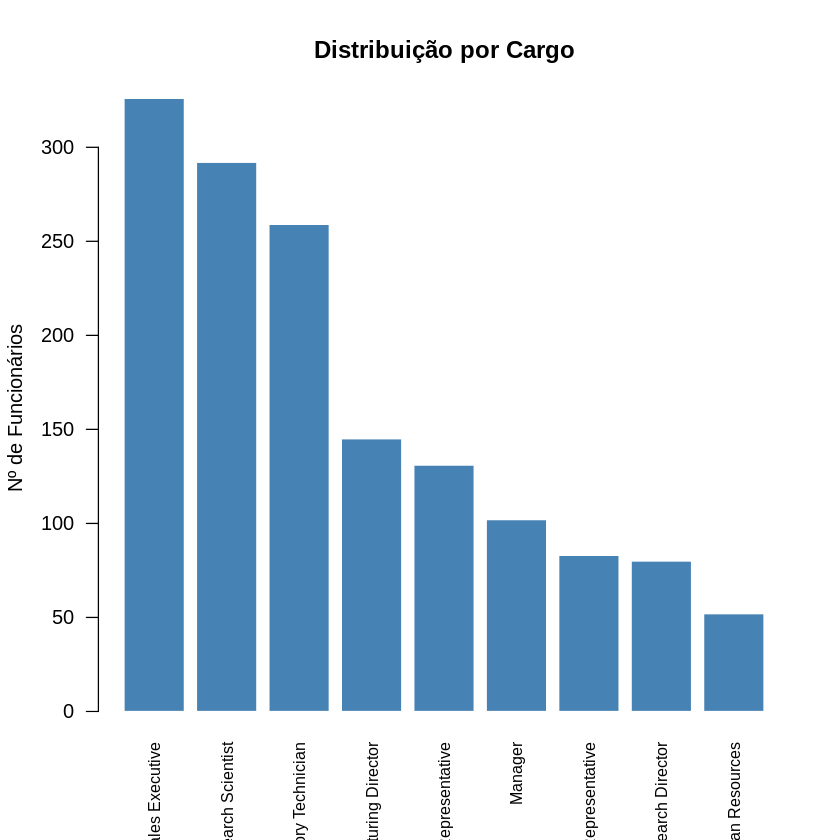

In [58]:
barplot(sort(table(dfProjeto1$JobRole), decreasing = TRUE),
        main      = "Distribuição por Cargo",
        ylab      = "Nº de Funcionários",
        col       = "steelblue",
        border    = "white",
        las       = 2,
        cex.names = 0.8)

# Percentagens
round(prop.table(sort(table(dfProjeto1$JobRole), decreasing = TRUE)) * 100, 2)

**── 7.4 Marital Status ────────────────────────────────────────────────**

Para comparar grupos substitui dfProjeto1 por dfSaiu ou dfFicou em células separadas.


 Married   Single Divorced 
   45.78    31.97    22.24 

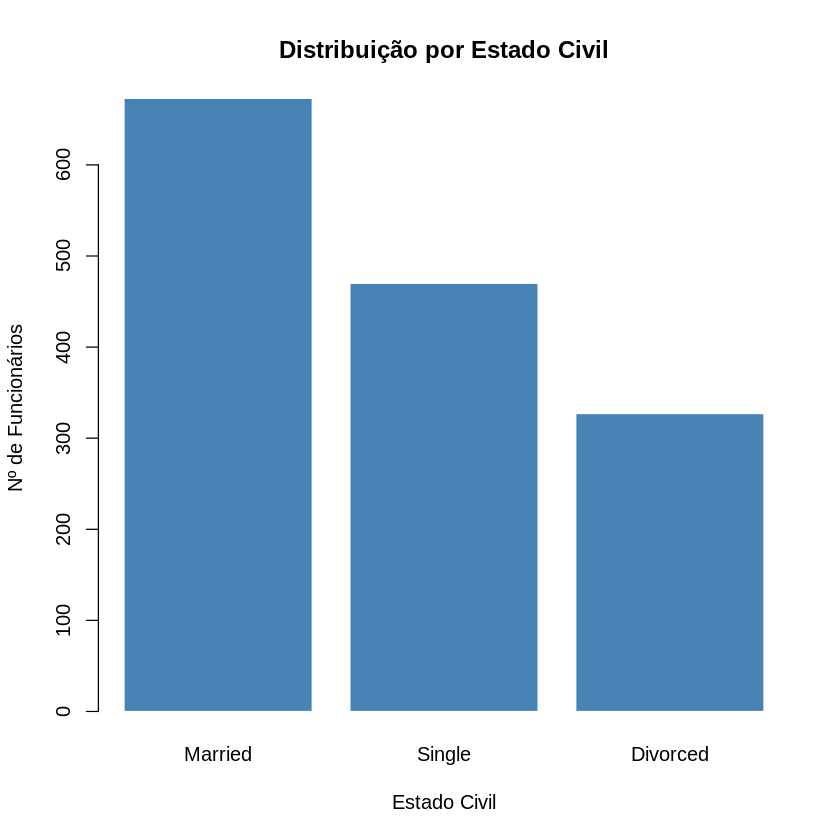

In [59]:
barplot(sort(table(dfProjeto1$MaritalStatus), decreasing = TRUE),
        main   = "Distribuição por Estado Civil",
        xlab   = "Estado Civil",
        ylab   = "Nº de Funcionários",
        col    = "steelblue",
        border = "white")

# Percentagens
round(prop.table(sort(table(dfProjeto1$MaritalStatus), decreasing = TRUE)) * 100, 2)

**── 7.4 Job Satisfaction ────────────────────────────────────────────────**

Para comparar grupos substitui dfProjeto1 por dfSaiu ou dfFicou em células separadas.


    1     2     3     4 
19.66 19.05 30.07 31.22 

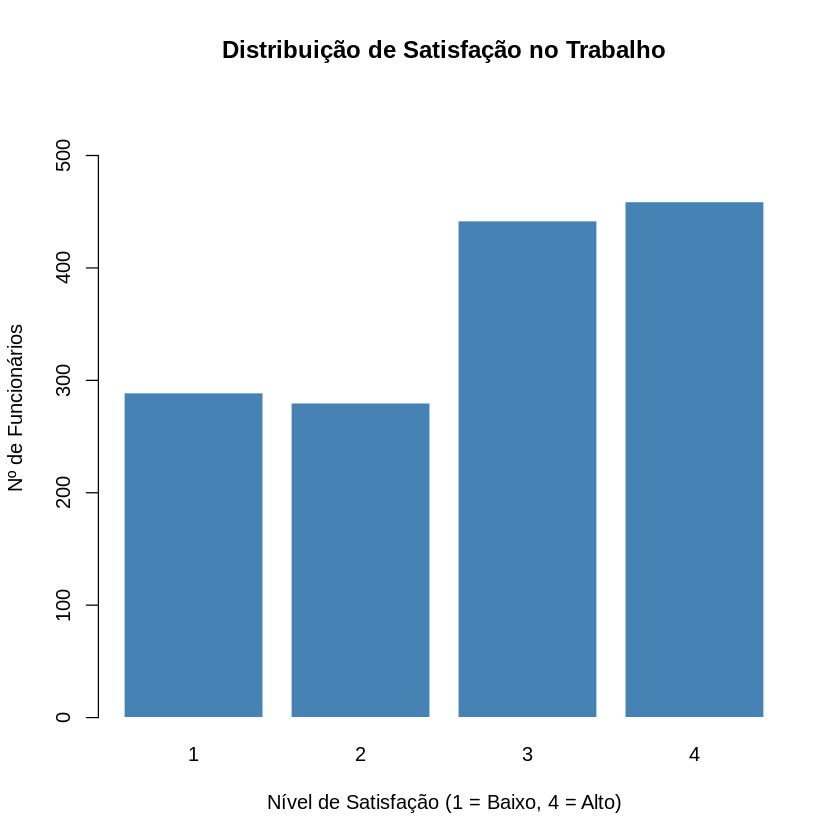

In [60]:
barplot(table(dfProjeto1$JobSatisfaction),
        main   = "Distribuição de Satisfação no Trabalho",
        xlab   = "Nível de Satisfação (1 = Baixo, 4 = Alto)",
        ylab   = "Nº de Funcionários",
        col    = "steelblue",
        border = "white",
        ylim   = c(0, max(table(dfProjeto1$JobSatisfaction)) * 1.2))

# Percentagens
round(prop.table(table(dfProjeto1$JobSatisfaction)) * 100, 2)

**── FASE 8: Correlações ───────────────────────────────────────────**

Para comparar grupos substitui dfNum por dfNumSaiu ou dfNumFicou.

**── 8.1 Matriz de correlação ─────────────────────────────────────**

Para comparar grupos substitui dfNum por dfNumSaiu ou dfNumFicou.

matrizCorSaiu <- cor(dfNumSaiu, use = "complete.obs")

e substitui matrizCor no pheatmap.

In [92]:
matrizCor <- cor(
  dfNum,                # dataframe só com colunas numéricas
  use = "complete.obs") # ignora linhas com NAs no cálculo

Ver as correlações com uma variável específica

Substitui "MonthlyIncome" pela variável que interessa.

In [93]:
sort(
  matrizCor["MonthlyIncome", ],  # linha da variável de interesse
  decreasing = TRUE)             # ordena da mais forte para a mais fraca

MonthlyIncome        TotalWorkingYears           YearsAtCompany 
             1.000000000              0.772893246              0.514284826 
                     Age       YearsInCurrentRole  YearsSinceLastPromotion 
             0.497854567              0.363817667              0.344977638 
    YearsWithCurrManager       NumCompaniesWorked                Education 
             0.344078883              0.149515216              0.094960677 
             MonthlyRate RelationshipSatisfaction                DailyRate 
             0.034813626              0.025873436              0.007707059 
        StockOptionLevel  EnvironmentSatisfaction           EmployeeNumber 
             0.005407677             -0.006259088             -0.014828516 
          JobInvolvement               HourlyRate         DistanceFromHome 
            -0.015271491             -0.015794304             -0.017014445 
   TrainingTimesLastYear        PercentSalaryHike 
            -0.021736277             -0.027268586

**── 8.2a pheatmap com clustering automático ──────────────────────**

Azul = correlação negativa | Branco = sem correlação | Vermelho = correlação positiva

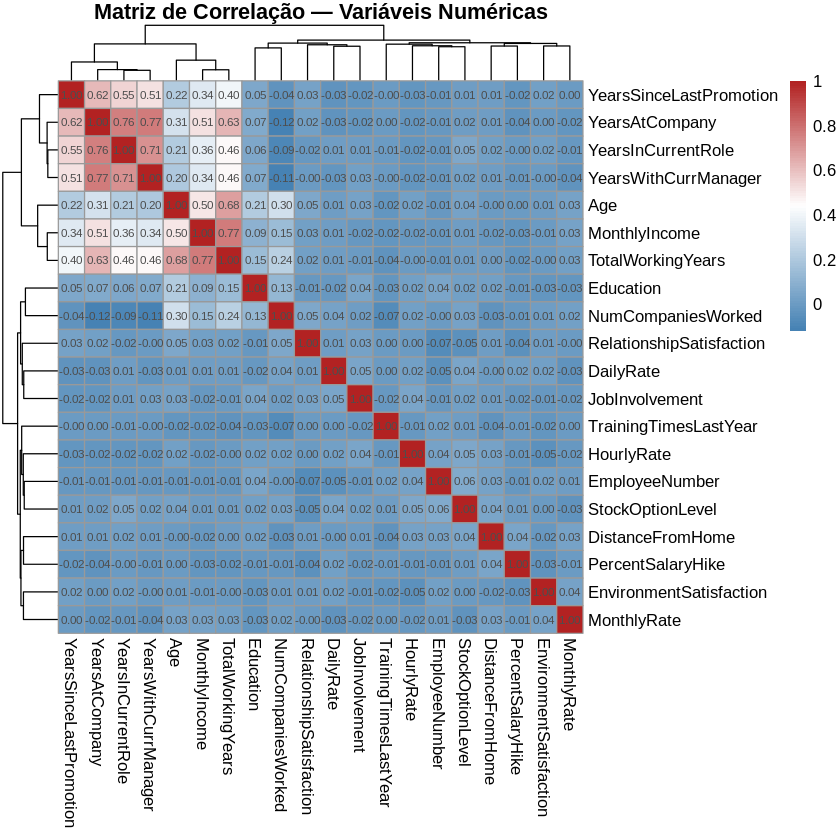

In [94]:
pheatmap(
  matrizCor,                                                    # matriz de correlação calculada em 8.1
  main            = "Matriz de Correlação — Variáveis Numéricas", # título do gráfico
  color           = colorRampPalette(                           # paleta de cores personalizada
    c("steelblue", "white", "firebrick"))(100),                 # azul (negativo) → branco (zero) → vermelho (positivo)
  display_numbers = TRUE,                                       # mostrar os valores numéricos em cada célula
  number_format   = "%.2f",                                     # formato dos números (2 casas decimais)
  fontsize_number = 7,                                          # tamanho dos números dentro das células
  treeheight_row  = 30,                                         # altura do dendrograma das linhas
  treeheight_col  = 30)                                         # altura do dendrograma das colunas

**── 8.2b pheatmap sem clustering (ordem original das colunas) ────**

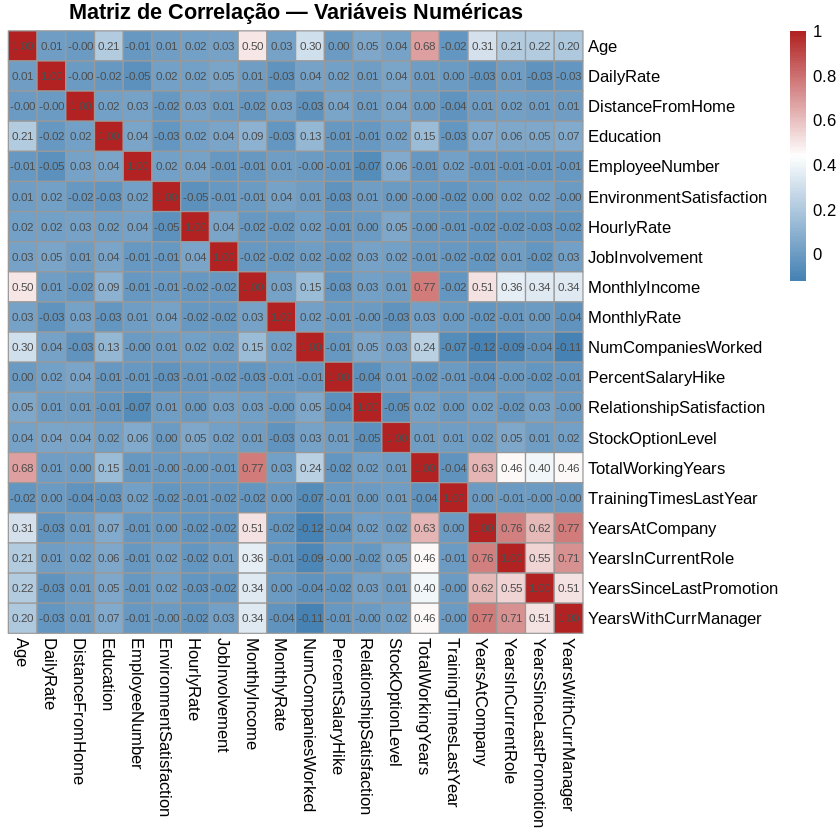

In [95]:
pheatmap(
  matrizCor,                                                    # matriz de correlação calculada em 8.1
  main            = "Matriz de Correlação — Variáveis Numéricas", # título do gráfico
  color           = colorRampPalette(
    c("steelblue", "white", "firebrick"))(100),                 # azul (negativo) → branco (zero) → vermelho (positivo)
  display_numbers = TRUE,                                       # mostrar os valores numéricos em cada célula
  number_format   = "%.2f",                                     # formato dos números (2 casas decimais)
  fontsize_number = 7,                                          # tamanho dos números dentro das células
  treeheight_row  = 0,                                          # 0 = esconde o dendrograma das linhas
  treeheight_col  = 0,                                          # 0 = esconde o dendrograma das colunas
  cluster_rows    = FALSE,                                      # desactiva clustering das linhas
  cluster_cols    = FALSE)                                      # desactiva clustering das colunas


**── 8.3 corrplot ─────────────────────────────────────────────────**

pheatmap é melhor para ver grupos, corrplot é melhor para leitura rápida dos valores individuais.

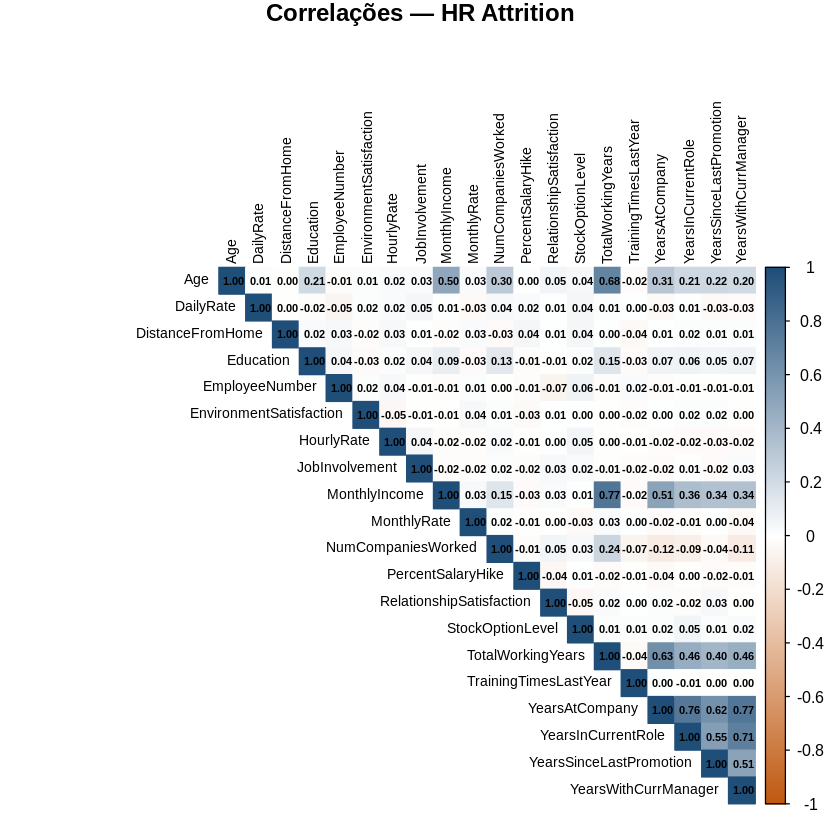

In [96]:
corrplot(
  matrizCor,                                                      # matriz de correlação calculada em 8.1
  method      = "color",                                          # células coloridas (alternativas: "circle", "number")
  type        = "upper",                                          # mostrar só triângulo superior (evita duplicação)
  tl.cex      = 0.7,                                              # tamanho dos rótulos das variáveis
  tl.col      = "black",                                          # cor dos rótulos
  addCoef.col = "black",                                          # mostrar valores numéricos a preto
  number.cex  = 0.55,                                             # tamanho dos números dentro das células
  col         = colorRampPalette(                                 # paleta de cores personalizada
    c("#C05911", "white", "#1F4E79"))(200),                       # laranja (negativo) → branco (zero) → azul (positivo)
  title       = "Correlações — HR Attrition",                     # título do gráfico
  mar         = c(0, 0, 1, 0))                                    # margens: baixo, esquerda, cima, direita

**── 8.4 Top 10 correlações mais fortes ───────────────────────────**

Para incluir Attrition nas correlações precisamos de a converter temporariamente para numérico (0 = No, 1 = Yes):

In [97]:
dfNumAttrition <- dfNum                                           # copia o dataframe numérico
dfNumAttrition$Attrition <- ifelse(                              # cria coluna Attrition numérica
  dfProjeto1$Attrition == "Yes", 1, 0)                           # Yes = 1, No = 0

In [103]:
# Calcular matriz de correlação com Attrition incluído
matrizCorAttrition <- cor(
  dfNumAttrition,       # dataframe com Attrition numérico incluído
  use = "complete.obs") # ignora linhas com NAs

In [110]:
cor_top <- as.data.frame(as.table(matrizCorAttrition)) %>%  # transforma matriz em tabela de 3 colunas: Var1, Var2, Freq
  filter(as.character(Var1) < as.character(Var2)) %>%        # mantém só pares únicos (ex: Age~JobLevel mas não JobLevel~Age)
  rename(correlacao = Freq) %>%                              # renomeia coluna Freq para correlacao
  mutate(abs_cor = abs(correlacao)) %>%                      # cria coluna com valor absoluto da correlação
  arrange(desc(abs_cor)) %>%                                 # ordena do mais forte para o mais fraco
  head(10)                                                   # mantém só os 10 primeiros

print(cor_top)

                      Var1                    Var2 correlacao   abs_cor
1            MonthlyIncome       TotalWorkingYears  0.7728932 0.7728932
2           YearsAtCompany    YearsWithCurrManager  0.7692124 0.7692124
3           YearsAtCompany      YearsInCurrentRole  0.7587537 0.7587537
4       YearsInCurrentRole    YearsWithCurrManager  0.7143648 0.7143648
5                      Age       TotalWorkingYears  0.6803805 0.6803805
6        TotalWorkingYears          YearsAtCompany  0.6281332 0.6281332
7           YearsAtCompany YearsSinceLastPromotion  0.6184089 0.6184089
8       YearsInCurrentRole YearsSinceLastPromotion  0.5480562 0.5480562
9            MonthlyIncome          YearsAtCompany  0.5142848 0.5142848
10 YearsSinceLastPromotion    YearsWithCurrManager  0.5102236 0.5102236


── 8.5 Correlação com variável alvo Attrition ─────────────────────────────



In [111]:
# Calcular correlações com Attrition
corAttrition <- cor(
  dfNumAttrition,       # dataframe com Attrition numérico incluído
  use = "complete.obs") # ignora linhas com NAs

In [112]:
# Extrair só a linha de Attrition e remover auto-correlação
corAttrition <- corAttrition["Attrition", ]                 # selecciona só a linha de Attrition
corAttrition <- corAttrition[names(corAttrition) != "Attrition"] # remove Attrition~Attrition (= 1)
corAttrition <- sort(corAttrition, decreasing = FALSE)      # ordena do mais negativo para o mais positivo

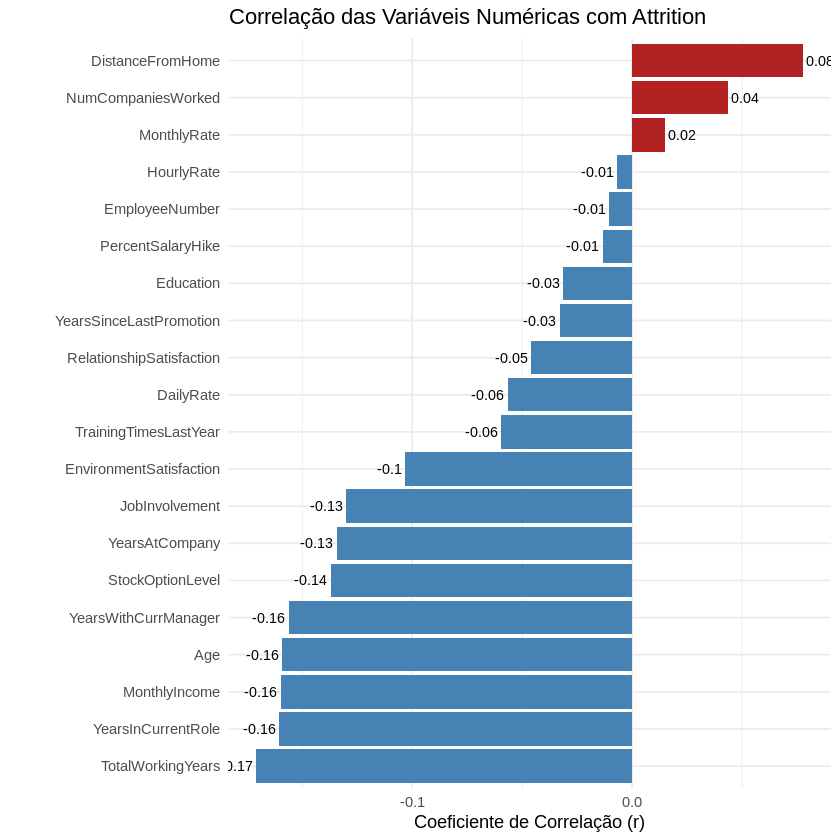

In [113]:
# Bar chart com ggplot2 (permite mostrar valores nas barras)
dfCorAttrition <- data.frame(                               # cria dataframe para o ggplot
  variavel    = names(corAttrition),                        # nomes das variáveis
  correlacao  = as.numeric(corAttrition))                   # valores de correlação

ggplot(dfCorAttrition,
       aes(x    = reorder(variavel, correlacao),            # ordena barras pelo valor de correlação
           y    = correlacao,                               # eixo Y = valor de correlação
           fill = correlacao > 0)) +                        # cor depende de positivo/negativo
  geom_col(show.legend = FALSE) +                          # barras sem legenda de cor
  geom_text(
    aes(label = round(correlacao, 2),                       # valor arredondado a 2 casas decimais
        hjust = ifelse(correlacao > 0, -0.1, 1.1)),         # alinha texto fora da barra
    size = 3) +                                             # tamanho do texto
  scale_fill_manual(values = c("steelblue", "firebrick")) + # azul = negativo, vermelho = positivo
  coord_flip() +                                           # barras horizontais
  labs(
    title = "Correlação das Variáveis Numéricas com Attrition", # título
    x     = NULL,                                          # sem label no eixo X (já tem os nomes)
    y     = "Coeficiente de Correlação (r)") +             # label do eixo Y
  theme_minimal()                                          # tema limpo sem fundo cinzento


**── FASE 9: Variável Alvo ─────────────────────────────────────────**

**── 9.1 Taxa de Attrition por Departamento ───────────────────────**

In [114]:
dfProjeto1 %>%
  group_by(Department) %>%                          # agrupa por departamento
  summarise(
    total    = n(),                                 # conta total de funcionários por grupo
    saiu     = sum(Attrition == "Yes"),             # conta quantos saíram
    taxa     = round(saiu / total * 100, 1)) %>%   # calcula percentagem de saída
  arrange(desc(taxa))                               # ordena do maior para o menor

Department,total,saiu,taxa
<fct>,<int>,<int>,<dbl>
Sales,446,92,20.6
Human Resources,63,12,19.0
Research & Development,961,133,13.8


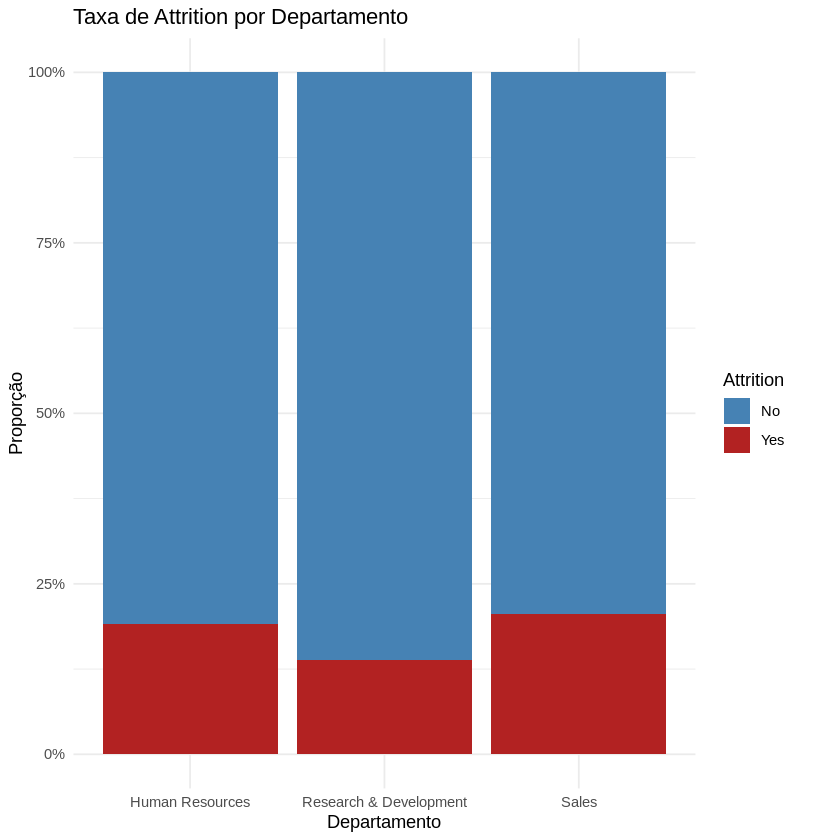

In [115]:
# Visualização
ggplot(dfProjeto1,
  aes(x    = Department,                            # eixo X = departamento
      fill = Attrition)) +                          # cor depende de Attrition
  geom_bar(position = "fill") +                     # barras empilhadas em percentagem (0% a 100%)
  scale_y_continuous(labels = scales::percent) +    # formata eixo Y em percentagem
  scale_fill_manual(
    values = c("No" = "steelblue",                  # cor para quem ficou
               "Yes" = "firebrick")) +              # cor para quem saiu
  labs(
    title = "Taxa de Attrition por Departamento",   # título do gráfico
    x     = "Departamento",                         # label eixo X
    y     = "Proporção",                            # label eixo Y
    fill  = "Attrition") +                          # label da legenda
  theme_minimal()                                   # tema limpo

**── 9.2 Taxa de Attrition por Cargo ──────────────────────────────**

In [116]:
dfProjeto1 %>%
  group_by(JobRole) %>%                             # agrupa por cargo
  summarise(
    total = n(),                                    # conta total de funcionários por grupo
    saiu  = sum(Attrition == "Yes"),                # conta quantos saíram
    taxa  = round(saiu / total * 100, 1)) %>%       # calcula percentagem de saída
  arrange(desc(taxa))                               # ordena do maior para o menor

JobRole,total,saiu,taxa
<fct>,<int>,<int>,<dbl>
Sales Representative,83,33,39.8
Laboratory Technician,259,62,23.9
Human Resources,52,12,23.1
Sales Executive,326,57,17.5
Research Scientist,292,47,16.1
Healthcare Representative,131,9,6.9
Manufacturing Director,145,10,6.9
Manager,102,5,4.9
Research Director,80,2,2.5


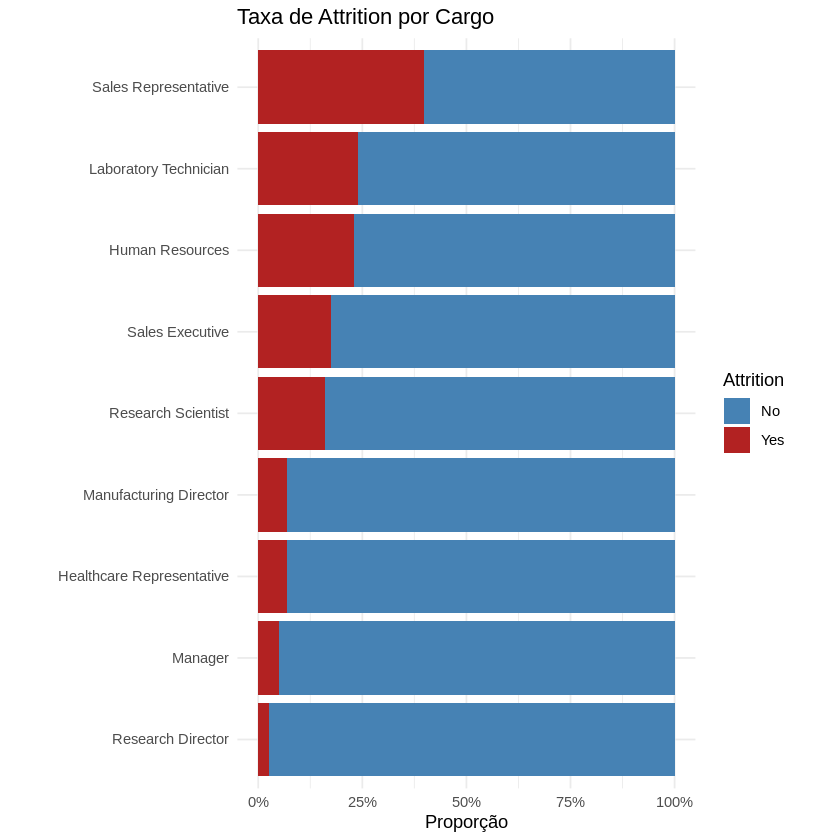

In [117]:
# Visualização
ggplot(dfProjeto1,
  aes(x    = reorder(JobRole, Attrition == "Yes"), # ordena cargos pela taxa de saída
      fill = Attrition)) +                          # cor depende de Attrition
  geom_bar(position = "fill") +                     # barras empilhadas em percentagem
  scale_y_continuous(labels = scales::percent) +    # formata eixo Y em percentagem
  scale_fill_manual(
    values = c("No" = "steelblue",                  # cor para quem ficou
               "Yes" = "firebrick")) +              # cor para quem saiu
  coord_flip() +                                    # barras horizontais — melhor para nomes longos
  labs(
    title = "Taxa de Attrition por Cargo",          # título do gráfico
    x     = NULL,                                   # sem label no eixo X
    y     = "Proporção",                            # label eixo Y
    fill  = "Attrition") +                          # label da legenda
  theme_minimal()                                   # tema limpo

**── 9.3 Attrition por Estado Civil ───────────────────────────────**

In [118]:
dfProjeto1 %>%
  group_by(MaritalStatus) %>%                       # agrupa por estado civil
  summarise(
    total = n(),                                    # conta total de funcionários por grupo
    saiu  = sum(Attrition == "Yes"),                # conta quantos saíram
    taxa  = round(saiu / total * 100, 1)) %>%       # calcula percentagem de saída
  arrange(desc(taxa))                               # ordena do maior para o menor

MaritalStatus,total,saiu,taxa
<fct>,<int>,<int>,<dbl>
Single,470,120,25.5
Married,673,84,12.5
Divorced,327,33,10.1


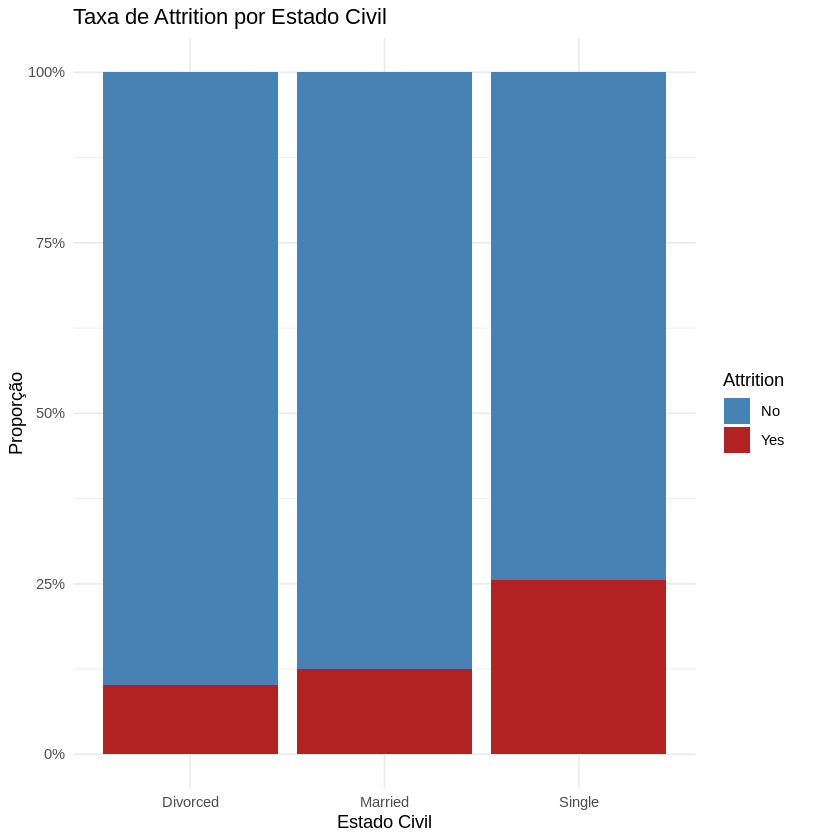

In [119]:
# Visualização
ggplot(dfProjeto1,
  aes(x    = reorder(MaritalStatus, Attrition == "Yes"), # ordena por taxa de saída
      fill = Attrition)) +                               # cor depende de Attrition
  geom_bar(position = "fill") +                          # barras empilhadas em percentagem
  scale_y_continuous(labels = scales::percent) +         # formata eixo Y em percentagem
  scale_fill_manual(
    values = c("No" = "steelblue",                       # cor para quem ficou
               "Yes" = "firebrick")) +                   # cor para quem saiu
  labs(
    title = "Taxa de Attrition por Estado Civil",        # título
    x     = "Estado Civil",                              # label eixo X
    y     = "Proporção",                                 # label eixo Y
    fill  = "Attrition") +                               # label da legenda
  theme_minimal()                                        # tema limpo

**── 9.4 Attrition por Satisfação no Trabalho ─────────────────────**

In [120]:
dfProjeto1 %>%
  group_by(JobSatisfaction) %>%                     # agrupa por nível de satisfação
  summarise(
    total = n(),                                    # conta total por grupo
    saiu  = sum(Attrition == "Yes"),                # conta quantos saíram
    taxa  = round(saiu / total * 100, 1)) %>%       # calcula percentagem de saída
  arrange(desc(taxa))                               # ordena do maior para o menor

JobSatisfaction,total,saiu,taxa
<fct>,<int>,<int>,<dbl>
1,289,66,22.8
3,442,73,16.5
2,280,46,16.4
4,459,52,11.3


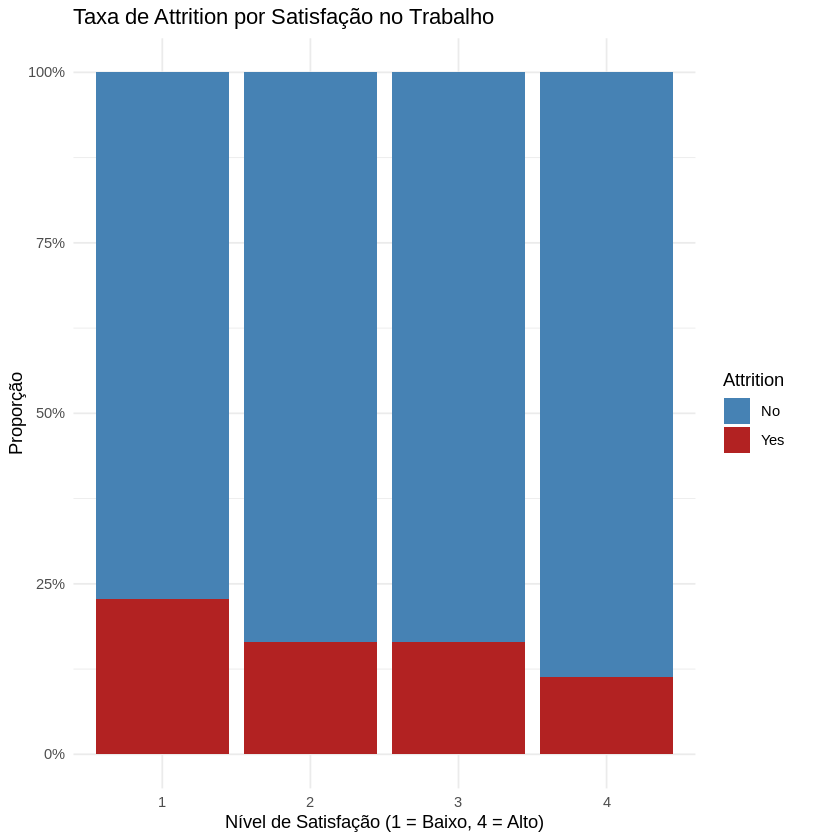

In [133]:
# ── Gráfico A: barras empilhadas em percentagem ──────────────────
ggplot(dfProjeto1,
  aes(x    = JobSatisfaction,                       # eixo X = nível de satisfação (1 a 4)
      fill = Attrition)) +                          # cor depende de Attrition
  geom_bar(position = "fill") +                     # barras empilhadas em percentagem (0% a 100%)
  scale_y_continuous(labels = scales::percent) +    # formata eixo Y em percentagem
  scale_fill_manual(
    values = c("No"  = "steelblue",                 # cor para quem ficou
               "Yes" = "firebrick")) +              # cor para quem saiu
  labs(
    title = "Taxa de Attrition por Satisfação no Trabalho", # título
    x     = "Nível de Satisfação (1 = Baixo, 4 = Alto)",    # label eixo X
    y     = "Proporção",                                     # label eixo Y
    fill  = "Attrition") +                                   # label da legenda
  theme_minimal()                                            # tema limpo

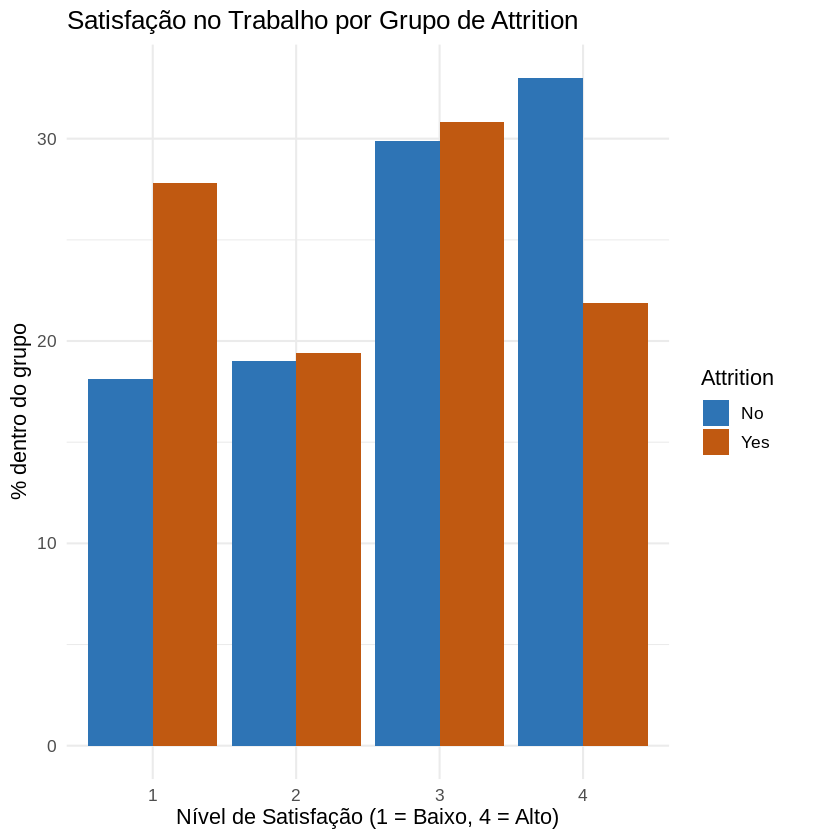

In [134]:
# ── Gráfico B: % dentro de cada grupo de Attrition ───────────────
dfProjeto1 %>%
  group_by(Attrition, JobSatisfaction) %>%          # agrupa por Attrition e satisfação
  summarise(n = n(), .groups = "drop") %>%          # conta por combinação de grupos
  group_by(Attrition) %>%                           # reagrupa só por Attrition
  mutate(pct = round(n / sum(n) * 100, 1)) %>%      # calcula % dentro de cada grupo de Attrition
  ggplot(aes(
    x    = factor(JobSatisfaction),                 # eixo X = nível de satisfação como factor
    y    = pct,                                     # eixo Y = percentagem dentro do grupo
    fill = Attrition)) +                            # cor depende de Attrition
  geom_col(position = "dodge") +                    # barras lado a lado (não empilhadas)
  scale_fill_manual(
    values = c("No"  = "#2E74B5",                   # cor para quem ficou
               "Yes" = "#C05911")) +                # cor para quem saiu
  labs(
    title = "Satisfação no Trabalho por Grupo de Attrition",  # título
    x     = "Nível de Satisfação (1 = Baixo, 4 = Alto)",      # label eixo X
    y     = "% dentro do grupo",                              # label eixo Y
    fill  = "Attrition") +                                    # label da legenda
  theme_minimal(base_size = 13)                               # tema limpo com texto maior

**── 9.5 Salário por Attrition ────────────────────────────────────**

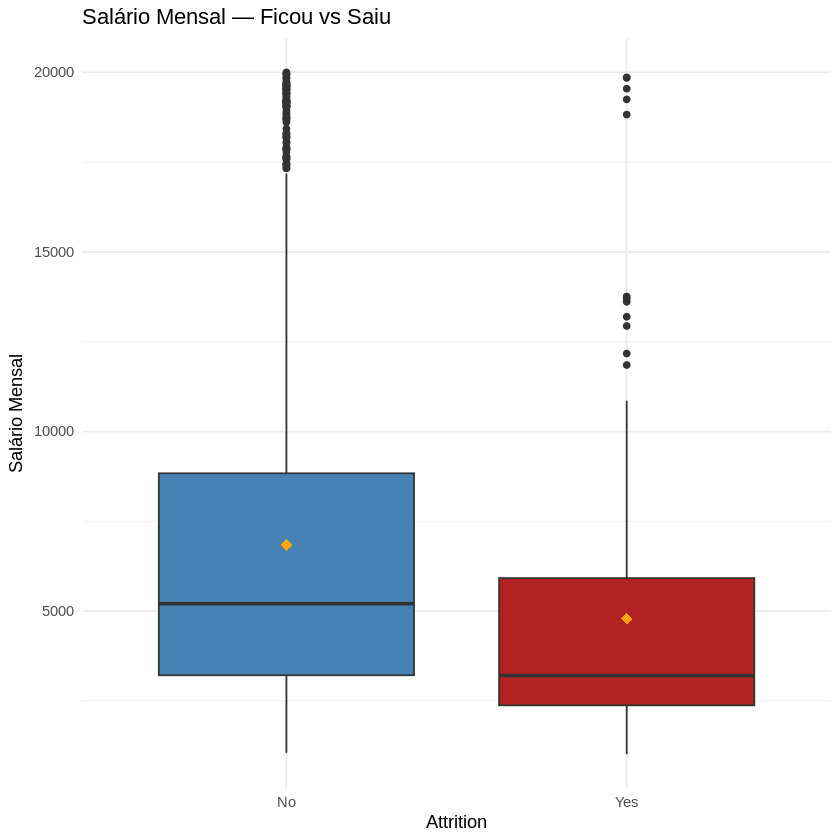

In [123]:
ggplot(dfProjeto1,
  aes(x    = Attrition,                             # eixo X = ficou vs saiu
      y    = MonthlyIncome,                         # eixo Y = salário mensal
      fill = Attrition)) +                          # cor depende de Attrition
  geom_boxplot(show.legend = FALSE) +               # boxplot sem legenda
  stat_summary(
    fun          = mean,                            # função a calcular = média
    geom         = "point",                         # representar como ponto
    shape        = 18,                              # forma do ponto = losango
    size         = 3,                               # tamanho do ponto
    color        = "orange",                        # cor do ponto
    show.legend  = FALSE) +                         # remove losango da legenda
  scale_fill_manual(
    values = c("No" = "steelblue",                  # cor para quem ficou
               "Yes" = "firebrick")) +              # cor para quem saiu
  labs(
    title   = "Salário Mensal — Ficou vs Saiu",     # título
    x       = "Attrition",                          # label eixo X
    y       = "Salário Mensal") +                   # label eixo Y
  theme_minimal()                                   # tema limpo

**── 9.6 Idade por Attrition ──────────────────────────────────────**

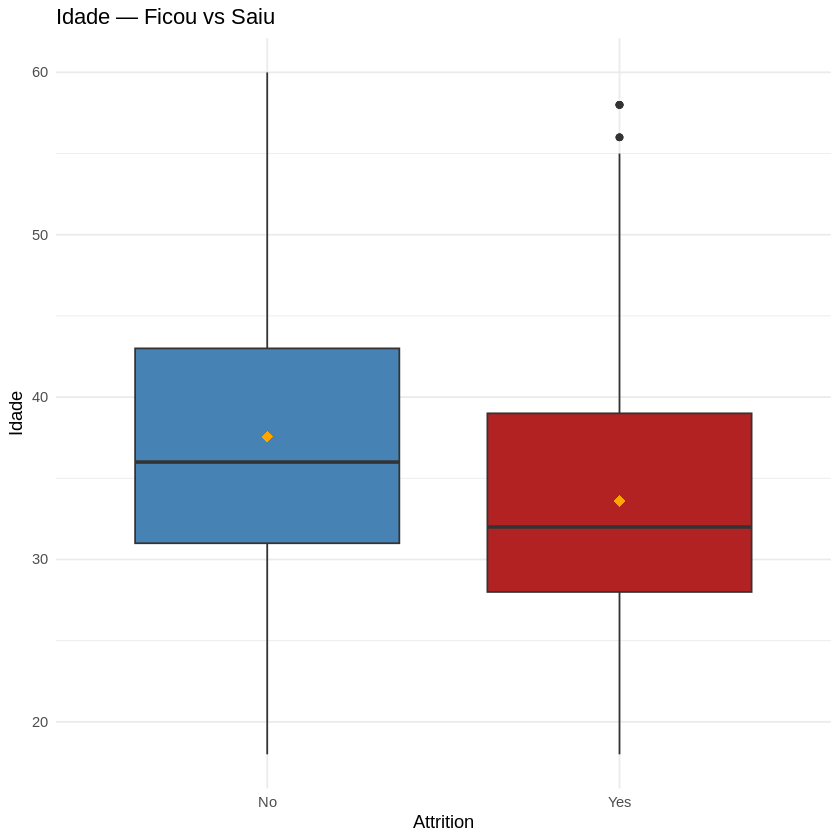

In [125]:
ggplot(dfProjeto1,
  aes(x    = Attrition,                             # eixo X = ficou vs saiu
      y    = Age,                                   # eixo Y = idade
      fill = Attrition)) +                          # cor depende de Attrition
  geom_boxplot(show.legend = FALSE) +               # boxplot sem legenda
  stat_summary(
    fun         = mean,                             # função a calcular = média
    geom        = "point",                          # representar como ponto
    shape       = 18,                               # forma do ponto = losango
    size        = 3,                                # tamanho do ponto
    color       = "orange",                         # cor do ponto
    show.legend = FALSE) +                          # remove losango da legenda
  scale_fill_manual(
    values = c("No" = "steelblue",                  # cor para quem ficou
               "Yes" = "firebrick")) +              # cor para quem saiu
  labs(
    title = "Idade — Ficou vs Saiu",                # título
    x     = "Attrition",                            # label eixo X
    y     = "Idade") +                              # label eixo Y
  theme_minimal()                                   # tema limpo

**── 9.7 Attrition por Overtime ────────────────────────────────────**

In [129]:
dfProjeto1 %>%
  group_by(OverTime) %>%                            # agrupa por overtime
  summarise(
    total = n(),                                    # conta total de funcionários por grupo
    saiu  = sum(Attrition == "Yes"),                # conta quantos saíram
    taxa  = round(saiu / total * 100, 1)) %>%       # calcula percentagem de saída
  arrange(desc(taxa))                               # ordena do maior para o menor

OverTime,total,saiu,taxa
<chr>,<int>,<int>,<dbl>
Yes,416,127,30.5
No,1054,110,10.4


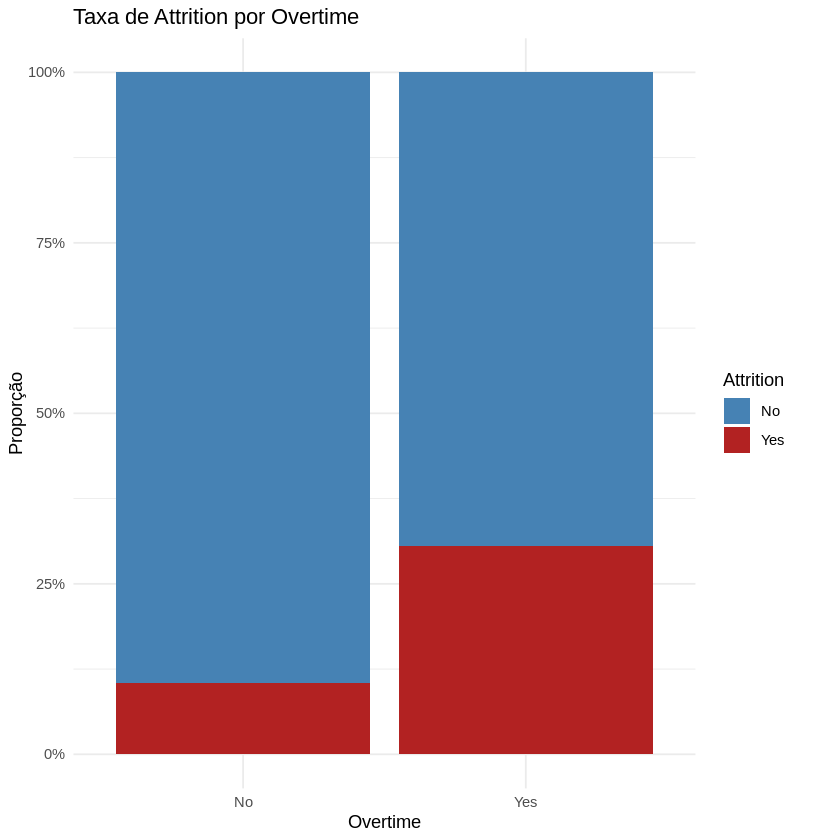

In [130]:
# Visualização
ggplot(dfProjeto1,
  aes(x    = OverTime,                              # eixo X = faz overtime ou não
      fill = Attrition)) +                          # cor depende de Attrition
  geom_bar(position = "fill") +                     # barras empilhadas em percentagem
  scale_y_continuous(labels = scales::percent) +    # formata eixo Y em percentagem
  scale_fill_manual(
    values = c("No" = "steelblue",                  # cor para quem ficou
               "Yes" = "firebrick")) +              # cor para quem saiu
  labs(
    title = "Taxa de Attrition por Overtime",       # título
    x     = "Overtime",                             # label eixo X
    y     = "Proporção",                            # label eixo Y
    fill  = "Attrition") +                          # label da legenda
  theme_minimal()                                   # tema limpo

**── 9.8 Heatmap: Attrition por Departamento × JobLevel  ────────────────────────────────────**

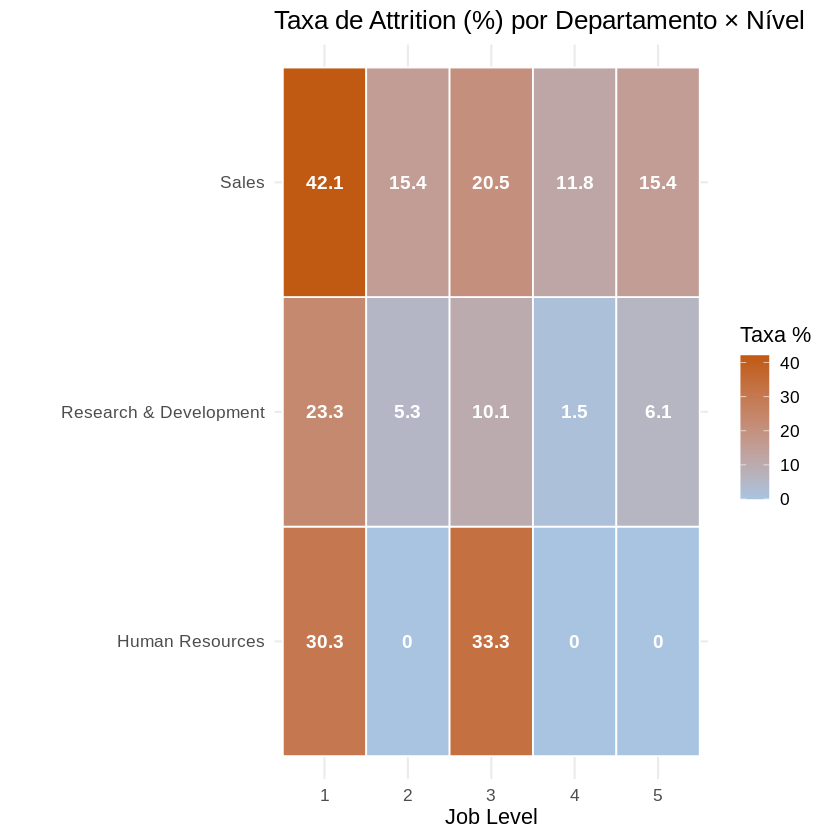

In [135]:
dfProjeto1 %>%
  group_by(Department, JobLevel) %>%                # agrupa por departamento e nível de cargo
  summarise(
    taxa = mean(Attrition == "Yes") * 100,          # calcula taxa de attrition em percentagem
    .groups = "drop") %>%                           # remove agrupamento após summarise
  ggplot(aes(
    x    = factor(JobLevel),                        # eixo X = nível de cargo como factor
    y    = Department,                              # eixo Y = departamento
    fill = taxa)) +                                 # cor depende da taxa de attrition
  geom_tile(
    color     = "white",                            # cor da borda de cada célula
    linewidth = 0.5) +                              # espessura da borda
  geom_text(
    aes(label = round(taxa, 1)),                    # mostra valor da taxa em cada célula
    color    = "white",                             # cor do texto
    fontface = "bold",                              # texto a negrito
    size     = 4) +                                 # tamanho do texto
  scale_fill_gradient(
    low  = "#A9C4E0",                               # cor para taxa baixa (azul claro)
    high = "#C05911",                               # cor para taxa alta (laranja)
    name = "Taxa %") +                              # label da legenda
  labs(
    title = "Taxa de Attrition (%) por Departamento × Nível", # título
    x     = "Job Level",                            # label eixo X
    y     = "") +                                   # sem label no eixo Y
  theme_minimal(base_size = 13)                     # tema limpo com texto maior

**── 9.9 Perfil de quem saiu: proporção que fazia Overtime   ────────────────────────────────────**

In [136]:
dfSaiu %>%
  group_by(OverTime) %>%                            # agrupa por overtime
  summarise(
    n   = n(),                                      # conta por grupo
    pct = round(n / nrow(dfSaiu) * 100, 1)) %>%    # percentagem dentro dos que saíram
  arrange(desc(pct))                                # ordena do maior para o menor

OverTime,n,pct
<chr>,<int>,<dbl>
Yes,127,53.6
No,110,46.4


**── FASE 10: Análise de Quem Ficou ───────────────────────────────**

**── 10.1 Correlações — Quem Ficou ────────────────────────────────**

In [137]:
# Calcular matriz
matrizCorFicou <- cor(
  dfNumFicou,               # dataframe numérico de quem ficou
  use = "complete.obs")     # ignora linhas com NAs

In [138]:
# Top 10 pares mais correlacionados
cor_top_ficou <- as.data.frame(as.table(matrizCorFicou)) %>%  # transforma matriz em tabela: Var1, Var2, Freq
  filter(as.character(Var1) < as.character(Var2)) %>%          # mantém só pares únicos
  rename(correlacao = Freq) %>%                                # renomeia coluna Freq para correlacao
  mutate(abs_cor = abs(correlacao)) %>%                        # cria coluna com valor absoluto
  arrange(desc(abs_cor)) %>%                                   # ordena do mais forte para o mais fraco
  head(10)                                                     # mantém só os 10 primeiros

print(cor_top_ficou)

                 Var1                    Var2 correlacao   abs_cor
1       MonthlyIncome       TotalWorkingYears  0.7716383 0.7716383
2      YearsAtCompany    YearsWithCurrManager  0.7643088 0.7643088
3      YearsAtCompany      YearsInCurrentRole  0.7450998 0.7450998
4  YearsInCurrentRole    YearsWithCurrManager  0.6962315 0.6962315
5                 Age       TotalWorkingYears  0.6727528 0.6727528
6      YearsAtCompany YearsSinceLastPromotion  0.6049505 0.6049505
7   TotalWorkingYears          YearsAtCompany  0.5944686 0.5944686
8  YearsInCurrentRole YearsSinceLastPromotion  0.5277249 0.5277249
9       MonthlyIncome          YearsAtCompany  0.4873148 0.4873148
10                Age           MonthlyIncome  0.4867127 0.4867127


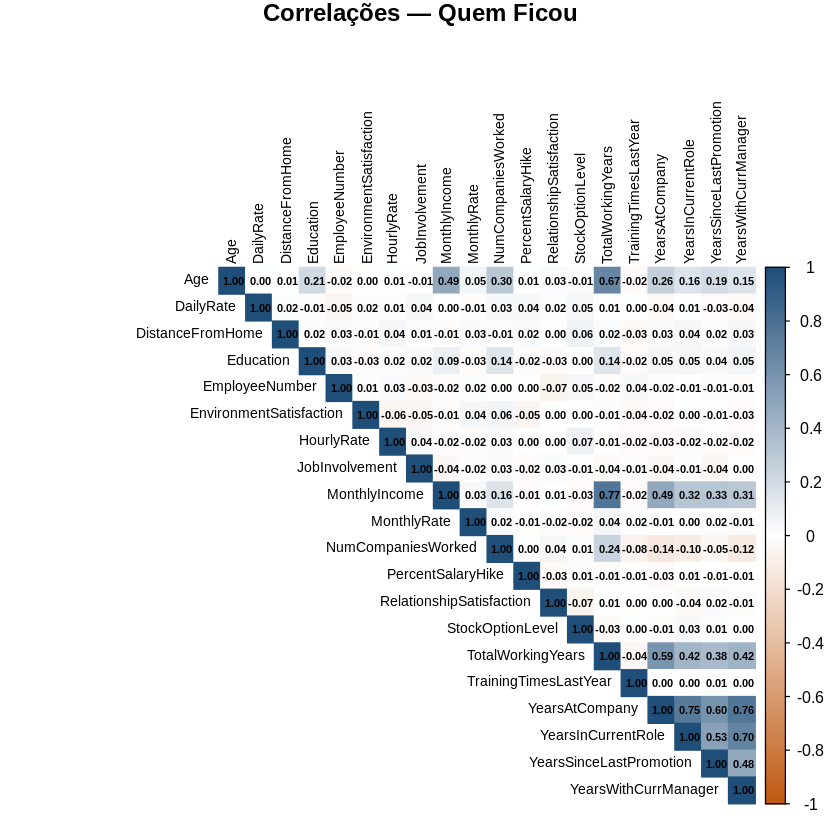

In [139]:
# Visualização com corrplot
corrplot(
  matrizCorFicou,                                               # matriz de correlação de quem ficou
  method      = "color",                                        # células coloridas
  type        = "upper",                                        # só triângulo superior
  tl.cex      = 0.7,                                            # tamanho dos rótulos
  tl.col      = "black",                                        # cor dos rótulos
  addCoef.col = "black",                                        # valores numéricos a preto
  number.cex  = 0.55,                                           # tamanho dos números
  col         = colorRampPalette(
    c("#C05911", "white", "#1F4E79"))(200),                     # laranja (negativo) → branco → azul (positivo)
  title       = "Correlações — Quem Ficou",                     # título
  mar         = c(0, 0, 1, 0))                                  # margens: baixo, esquerda, cima, direita

**── 10.2 Salário × Experiência ───────────────────────────────────**

`geom_smooth()` using formula = 'y ~ x'


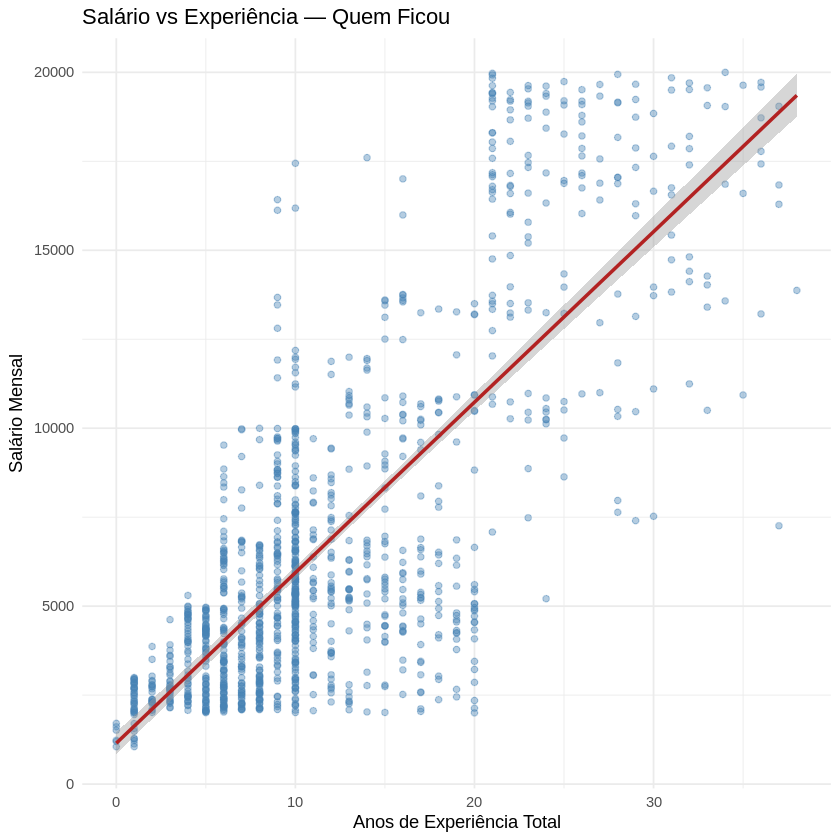

In [140]:
ggplot(dfFicou,
  aes(x = TotalWorkingYears,                        # eixo X = anos de experiência total
      y = MonthlyIncome)) +                         # eixo Y = salário mensal
  geom_point(
    alpha = 0.4,                                    # transparência dos pontos
    color = "steelblue") +                          # cor dos pontos
  geom_smooth(
    method = "lm",                                  # linha de tendência linear
    color  = "firebrick",                           # cor da linha
    se     = TRUE) +                                # mostrar intervalo de confiança a sombreado
  labs(
    title = "Salário vs Experiência — Quem Ficou",  # título
    x     = "Anos de Experiência Total",            # label eixo X
    y     = "Salário Mensal") +                     # label eixo Y
  theme_minimal()                                   # tema limpo

**── 10.3 Estabilidade ────────────────────────────────────────────**

`geom_smooth()` using formula = 'y ~ x'


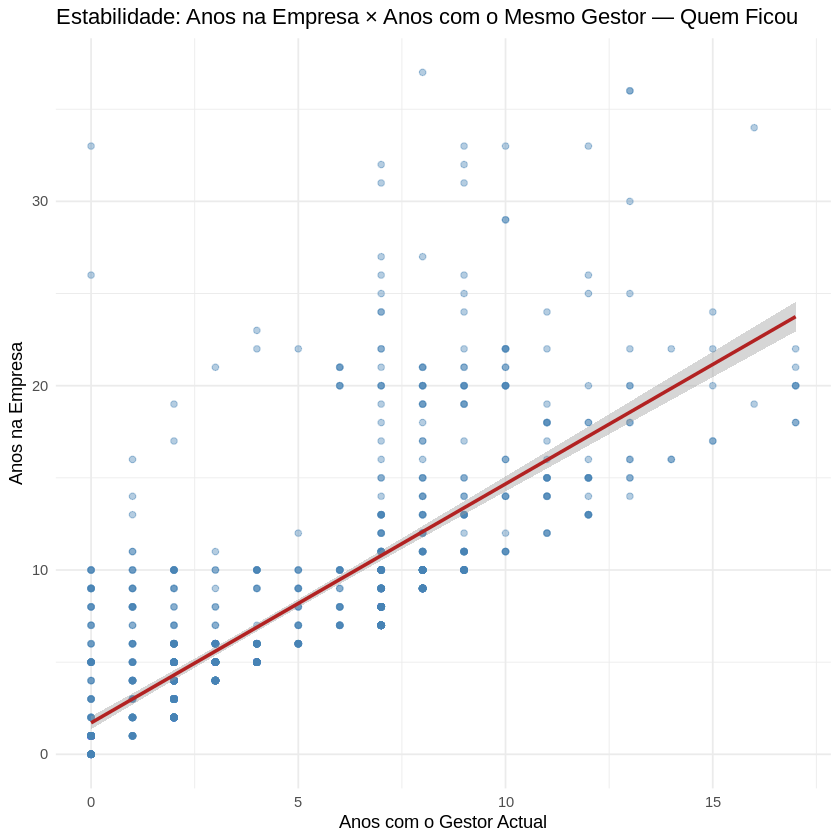

In [143]:
ggplot(dfFicou,
  aes(x = YearsWithCurrManager,                     # eixo X = anos com o gestor actual
      y = YearsAtCompany)) +                        # eixo Y = anos na empresa
  geom_point(
    alpha = 0.4,                                    # transparência dos pontos
    color = "steelblue") +                          # cor dos pontos
  geom_smooth(
    method = "lm",                                  # linha de tendência linear
    color  = "firebrick",                           # cor da linha
    se     = TRUE) +                                # mostrar intervalo de confiança
  labs(
    title = "Estabilidade: Anos na Empresa × Anos com o Mesmo Gestor — Quem Ficou", # título
    x     = "Anos com o Gestor Actual",             # label eixo X
    y     = "Anos na Empresa") +                    # label eixo Y
  theme_minimal()                                   # tema limpo

**── 10.4 Progressão ──────────────────────────────────────────────**

`geom_smooth()` using formula = 'y ~ x'


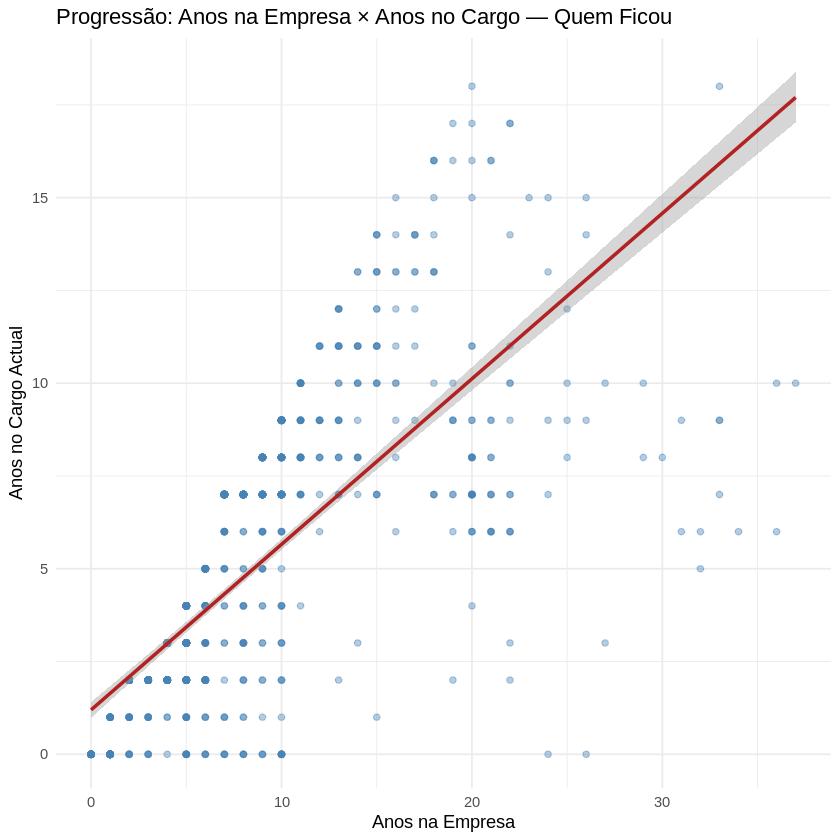

In [144]:
ggplot(dfFicou,
  aes(x = YearsAtCompany,                           # eixo X = anos na empresa
      y = YearsInCurrentRole)) +                    # eixo Y = anos no cargo actual
  geom_point(
    alpha = 0.4,                                    # transparência dos pontos
    color = "steelblue") +                          # cor dos pontos
  geom_smooth(
    method = "lm",                                  # linha de tendência linear
    color  = "firebrick",                           # cor da linha
    se     = TRUE) +                                # mostrar intervalo de confiança
  labs(
    title = "Progressão: Anos na Empresa × Anos no Cargo — Quem Ficou", # título
    x     = "Anos na Empresa",                      # label eixo X
    y     = "Anos no Cargo Actual") +               # label eixo Y
  theme_minimal()                                   # tema limpo

**── 10.5 Promoções ───────────────────────────────────────────────**

`geom_smooth()` using formula = 'y ~ x'


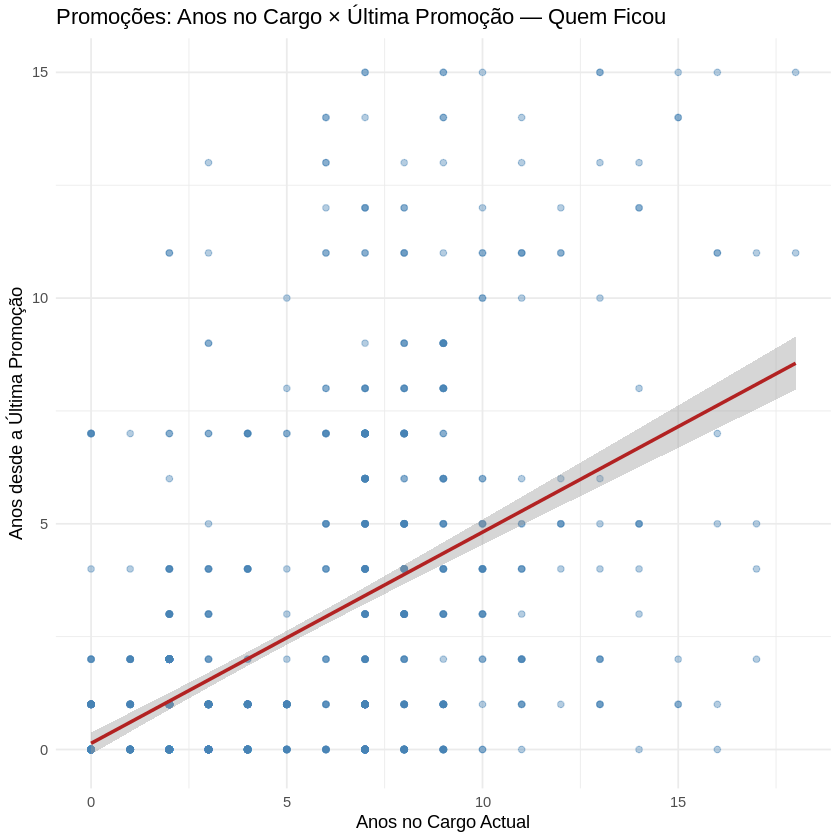

In [146]:
ggplot(dfFicou,
  aes(x = YearsInCurrentRole,                       # eixo X = anos no cargo actual
      y = YearsSinceLastPromotion)) +               # eixo Y = anos desde a última promoção
  geom_point(
    alpha = 0.4,                                    # transparência dos pontos
    color = "steelblue") +                          # cor dos pontos
  geom_smooth(
    method = "lm",                                  # linha de tendência linear
    color  = "firebrick",                           # cor da linha
    se     = TRUE) +                                # mostrar intervalo de confiança
  labs(
    title = "Promoções: Anos no Cargo × Última Promoção — Quem Ficou", # título
    x     = "Anos no Cargo Actual",                 # label eixo X
    y     = "Anos desde a Última Promoção") +       # label eixo Y
  theme_minimal()                                   # tema limpo

**── 10.6 Estrutura Salarial por Nível de Cargo ───────────────────**

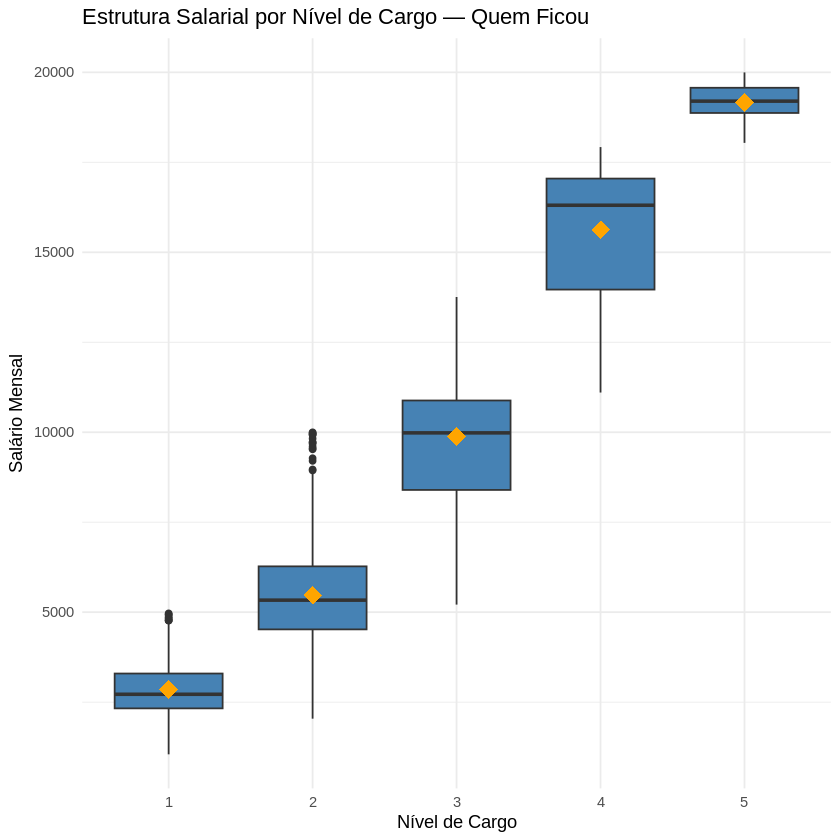

In [148]:
ggplot(dfFicou,
  aes(x = JobLevel,                                 # eixo X = nível de cargo
      y = MonthlyIncome)) +                         # eixo Y = salário mensal
  geom_boxplot(
    fill        = "steelblue",                      # cor igual para todas as caixas
    show.legend = FALSE) +                          # sem legenda
  stat_summary(
    fun         = mean,                             # função a calcular = média
    geom        = "point",                          # representar como ponto
    shape       = 18,                               # forma = losango
    size        = 5,                                # tamanho aumentado para maior visibilidade
    color       = "orange",                         # cor com contraste sobre steelblue
    show.legend = FALSE) +                          # sem legenda
  labs(
    title = "Estrutura Salarial por Nível de Cargo — Quem Ficou", # título
    x     = "Nível de Cargo",                       # label eixo X
    y     = "Salário Mensal") +                     # label eixo Y
  theme_minimal()                                   # tema limpo
                          # tema limpo